# Import Libraries

In [ ]:
# Importing Libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.metrics import (
    confusion_matrix, accuracy_score, classification_report,
    roc_auc_score, roc_curve, precision_score, recall_score, f1_score,
)
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
import warnings
warnings.simplefilter(action='ignore')
sns.set()
plt.style.use("ggplot")
%matplotlib inline


In [ ]:
# Models are imported directly from scikit-learn and xgboost (see imports cell).
# Previously this cell hand-rolled LR / KNN / SVC / DecisionTree / RandomForest /
# GradientBoosting / XGBClassifier / GridSearchCV in NumPy (~600 lines); those have
# been replaced with the standard library implementations.


# Loading Dataset

In [ ]:
df = pd.read_csv("diabetes.csv")

In [ ]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


# Data Info

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [ ]:
df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

In [ ]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [ ]:
# (row, columns)
df.shape

(768, 9)

In [ ]:
# distribution of outcome variable
df.Outcome.value_counts()*100/len(df)

,count
Outcome,
0,65.104167
1,34.895833


In [ ]:
df['Outcome'].value_counts()*100/len(df)

,count
Outcome,
0,65.104167
1,34.895833


In [ ]:
df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

# EDA


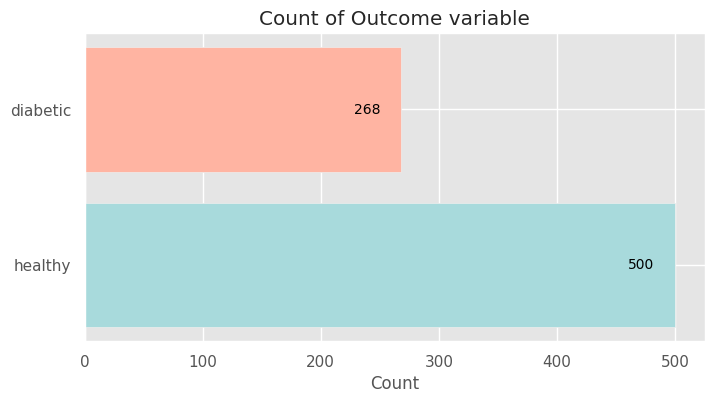

In [ ]:
# Checking Class imbalance (Bar Plot)
df['Outcome'] = df['Outcome'].map({0: 'healthy', 1: 'diabetic'})

# Count values
counts = df['Outcome'].value_counts()

# Plot
plt.figure(figsize=(8, 4))
bars = plt.barh(counts.index, counts.values, color=['#a8dadc', '#ffb4a2'])

# Add labels on bars
for bar in bars:
    width = bar.get_width()
    plt.text(width - 40, bar.get_y() + bar.get_height()/2,
             f'{int(width)}', va='center', color='black')

# Title and labels
plt.title('Count of Outcome variable')
plt.xlabel('Count')

plt.show()


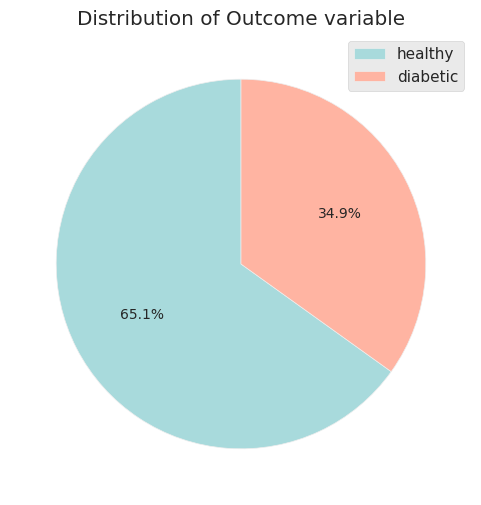

In [ ]:
# Checking Class imbalance (Pie Chart)
# Count values
counts = df['Outcome'].value_counts()

# Colors similar to your image
colors = ['#a8dadc', '#ffb4a2']  # blue, yellow

# Plot pie chart
plt.figure(figsize=(6,6))
plt.pie(
    counts,
    labels=None,                # no labels inside
    autopct='%1.1f%%',         # percentage format
    startangle=90,
    colors=colors
)

# Title
plt.title('Distribution of Outcome variable')

# Legend
plt.legend(counts.index, loc='upper right')

plt.show()

In [ ]:
#Convert back to numeric
df['Outcome'] = df['Outcome'].map({'healthy': 0, 'diabetic': 1})

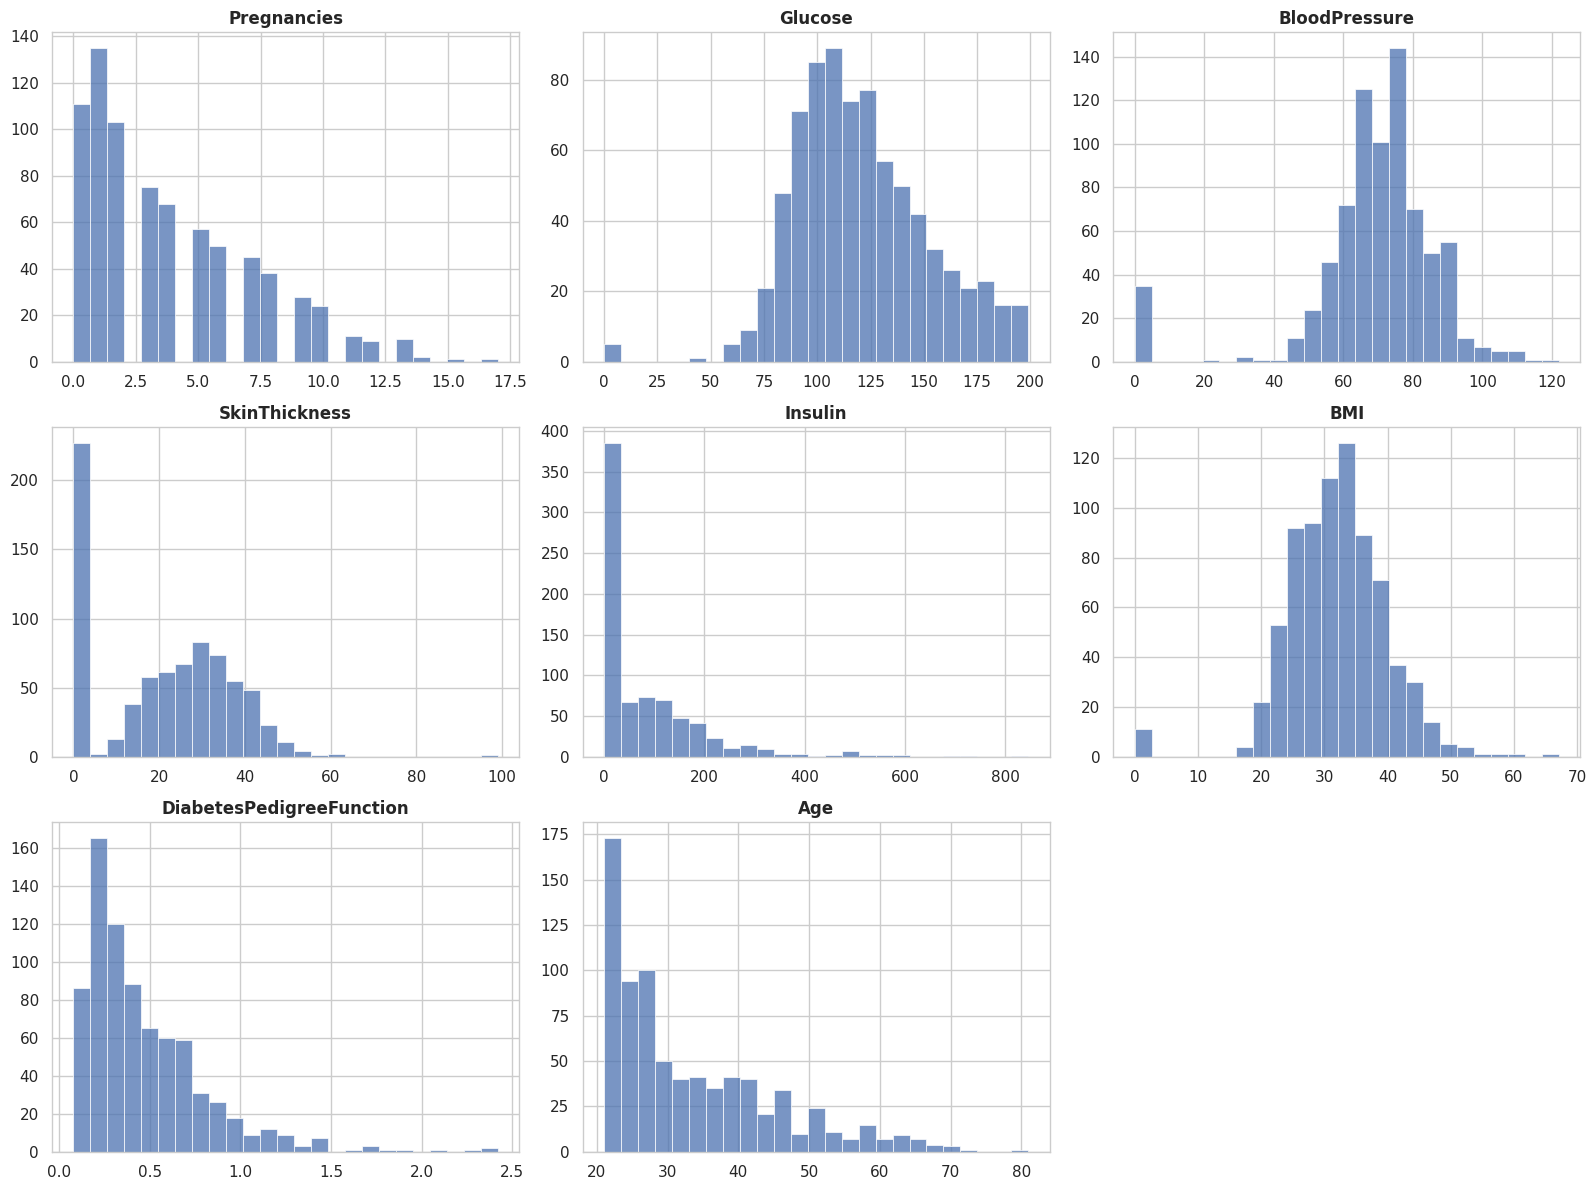

In [ ]:
# Histogram
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (16, 12)

# Exclude Outcome
num_cols = [col for col in df.select_dtypes(include=['int64', 'float64']).columns if col != 'Outcome']

rows = (len(num_cols) // 3) + 1
fig, axes = plt.subplots(rows, 3)
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.histplot(
        df[col],
        bins=25,
        ax=axes[i],
        color="#4C72B0"
    )

    axes[i].set_title(col, fontsize=12, fontweight='bold')
    axes[i].set_xlabel("")
    axes[i].set_ylabel("")

# Remove empty plots
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

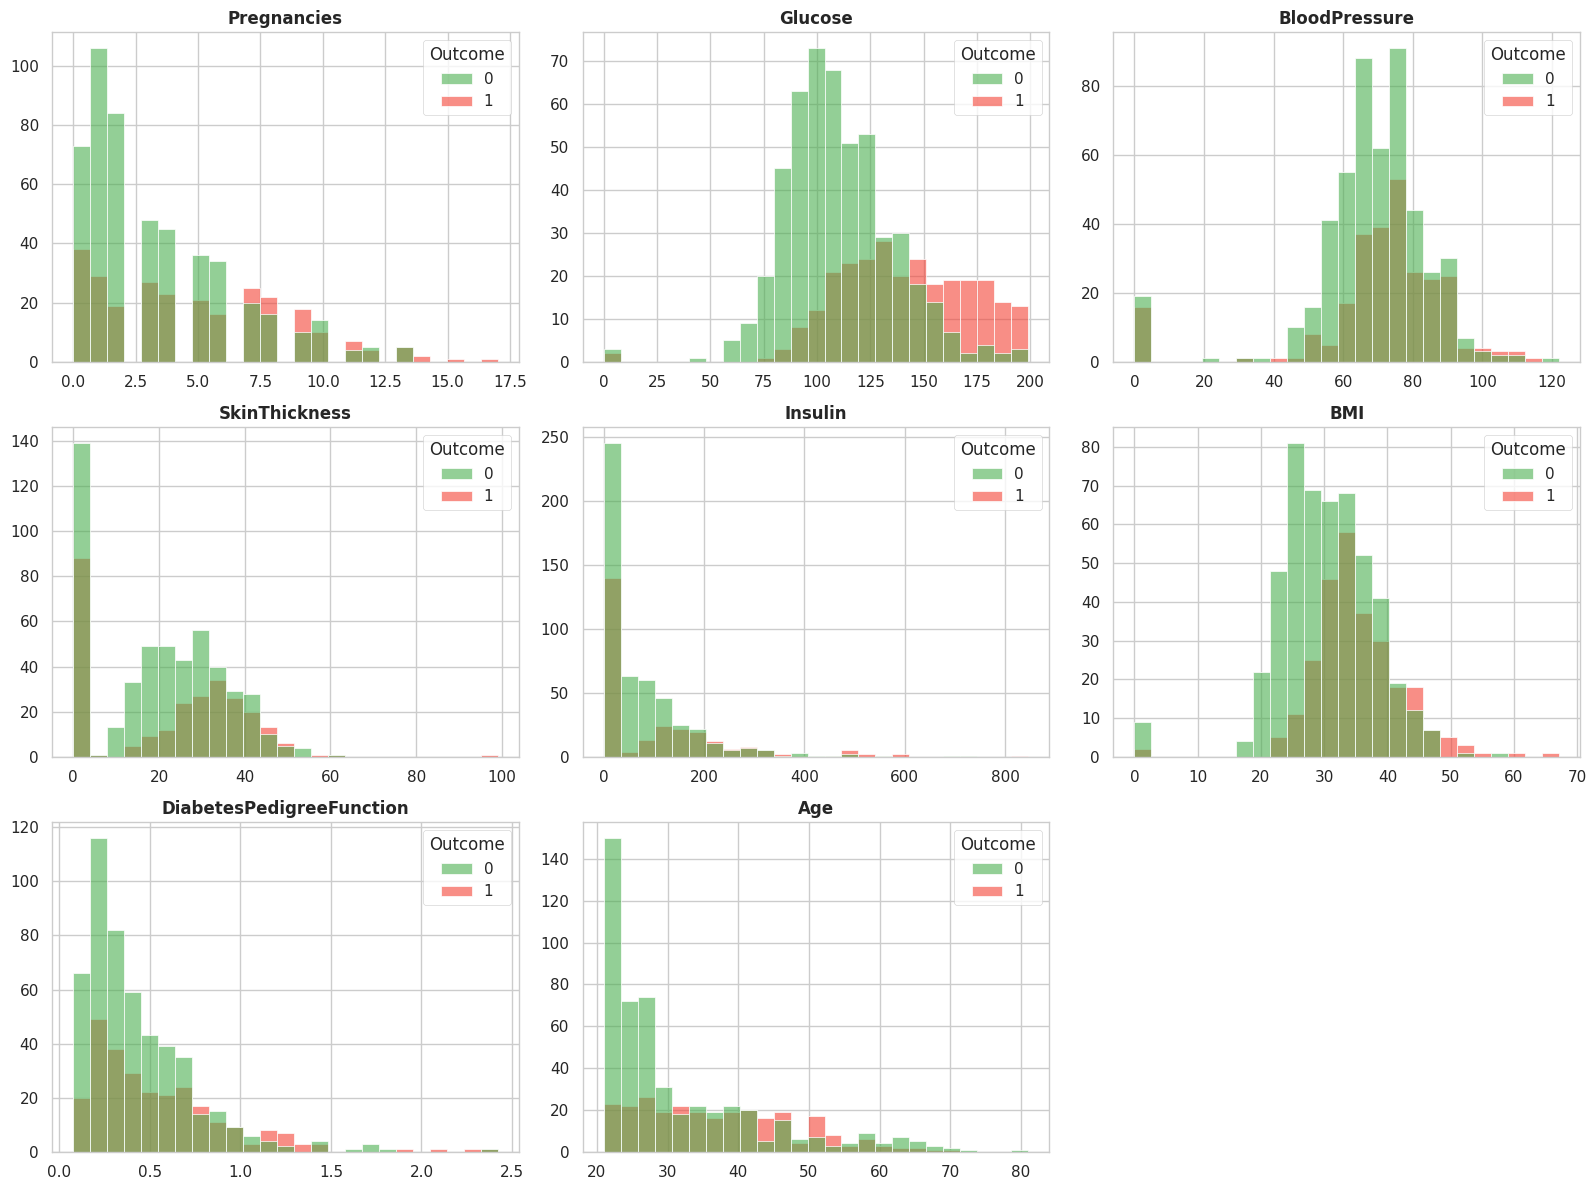

In [ ]:
# Histogram (by outcome)
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (16, 12)

num_cols = [col for col in df.select_dtypes(include=['int64', 'float64']).columns if col != 'Outcome']

rows = (len(num_cols) // 3) + 1
fig, axes = plt.subplots(rows, 3)
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.histplot(
        data=df,
        x=col,
        hue='Outcome',
        bins=25,
        palette=['#4CAF50', '#F44336'],
        alpha=0.6,
        kde=False,
        ax=axes[i]
    )

    axes[i].set_title(col, fontsize=12, fontweight='bold')
    axes[i].set_xlabel("")
    axes[i].set_ylabel("")

# Remove empty plots
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

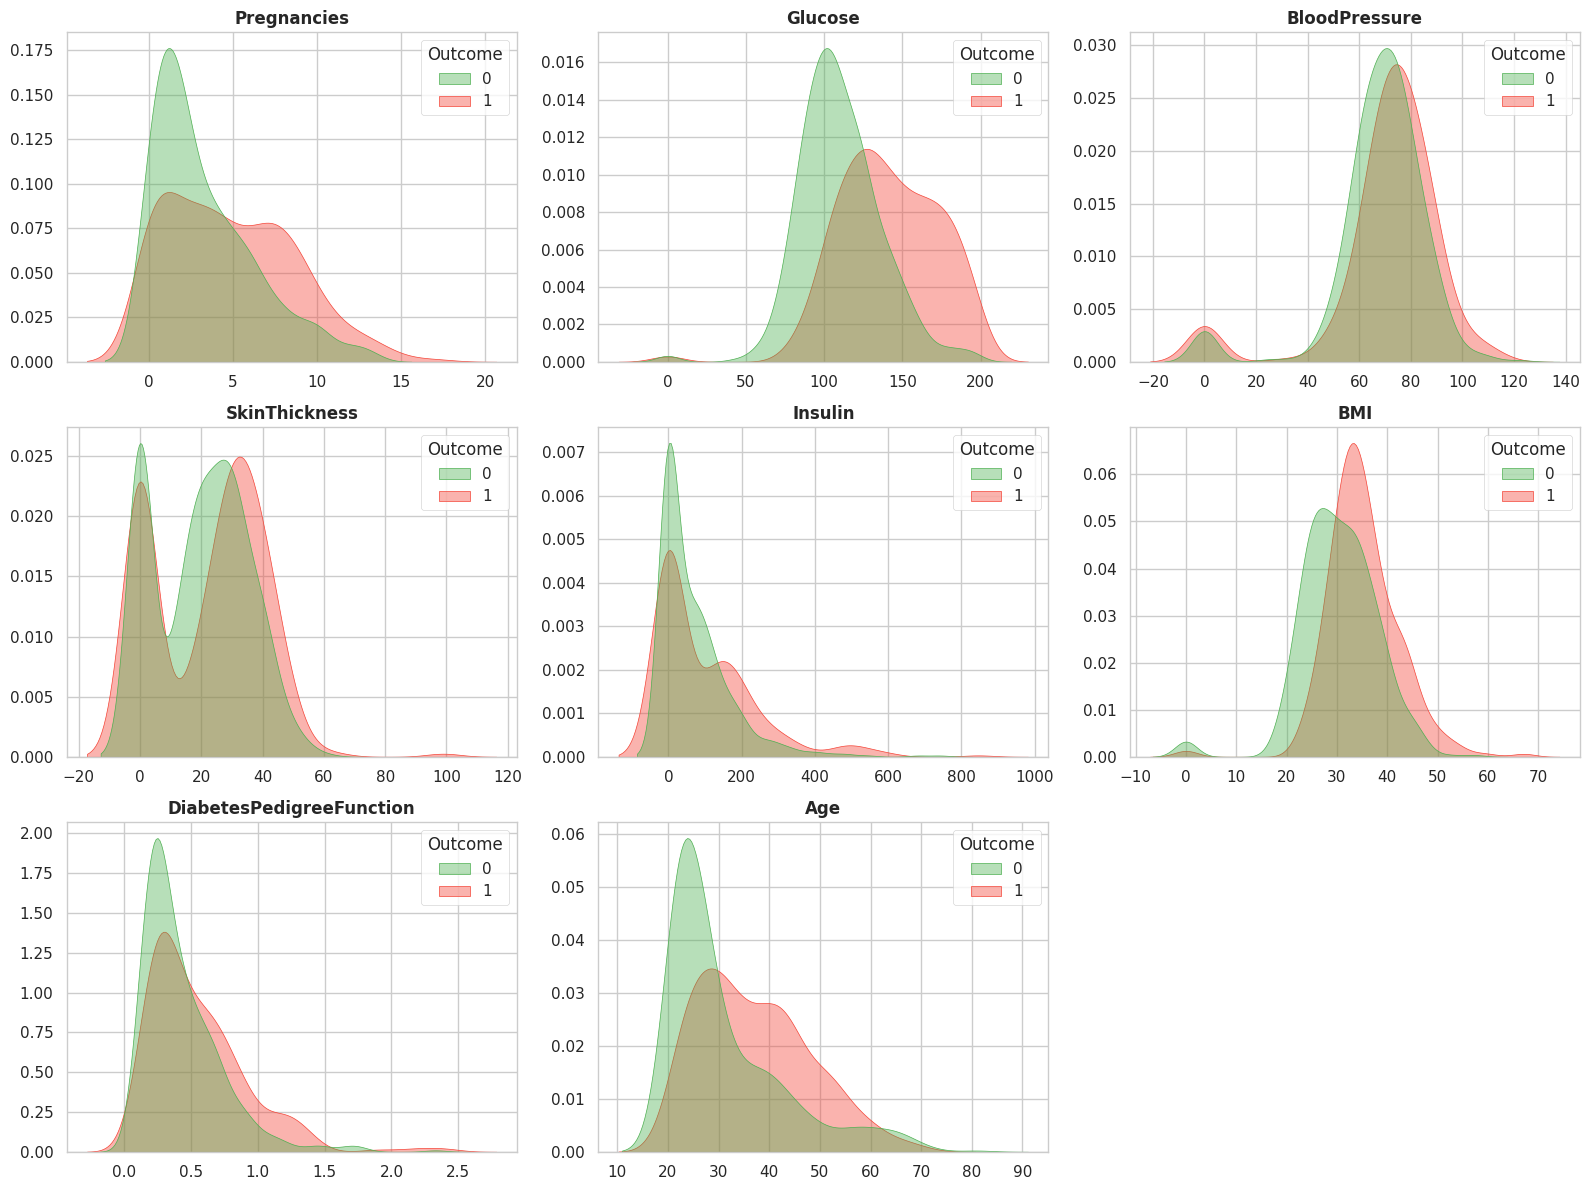

In [ ]:
# KDE (by outcome)
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (16, 12)

num_cols = [col for col in df.select_dtypes(include=['int64', 'float64']).columns if col != 'Outcome']

rows = (len(num_cols) // 3) + 1
fig, axes = plt.subplots(rows, 3)
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.kdeplot(
        data=df,
        x=col,
        hue='Outcome',
        fill=True,
        common_norm=False,
        palette=['#4CAF50', '#F44336'],
        alpha=0.4,
        ax=axes[i]
    )

    axes[i].set_title(col, fontsize=12, fontweight='bold')
    axes[i].set_xlabel("")
    axes[i].set_ylabel("")

# Remove empty plots
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

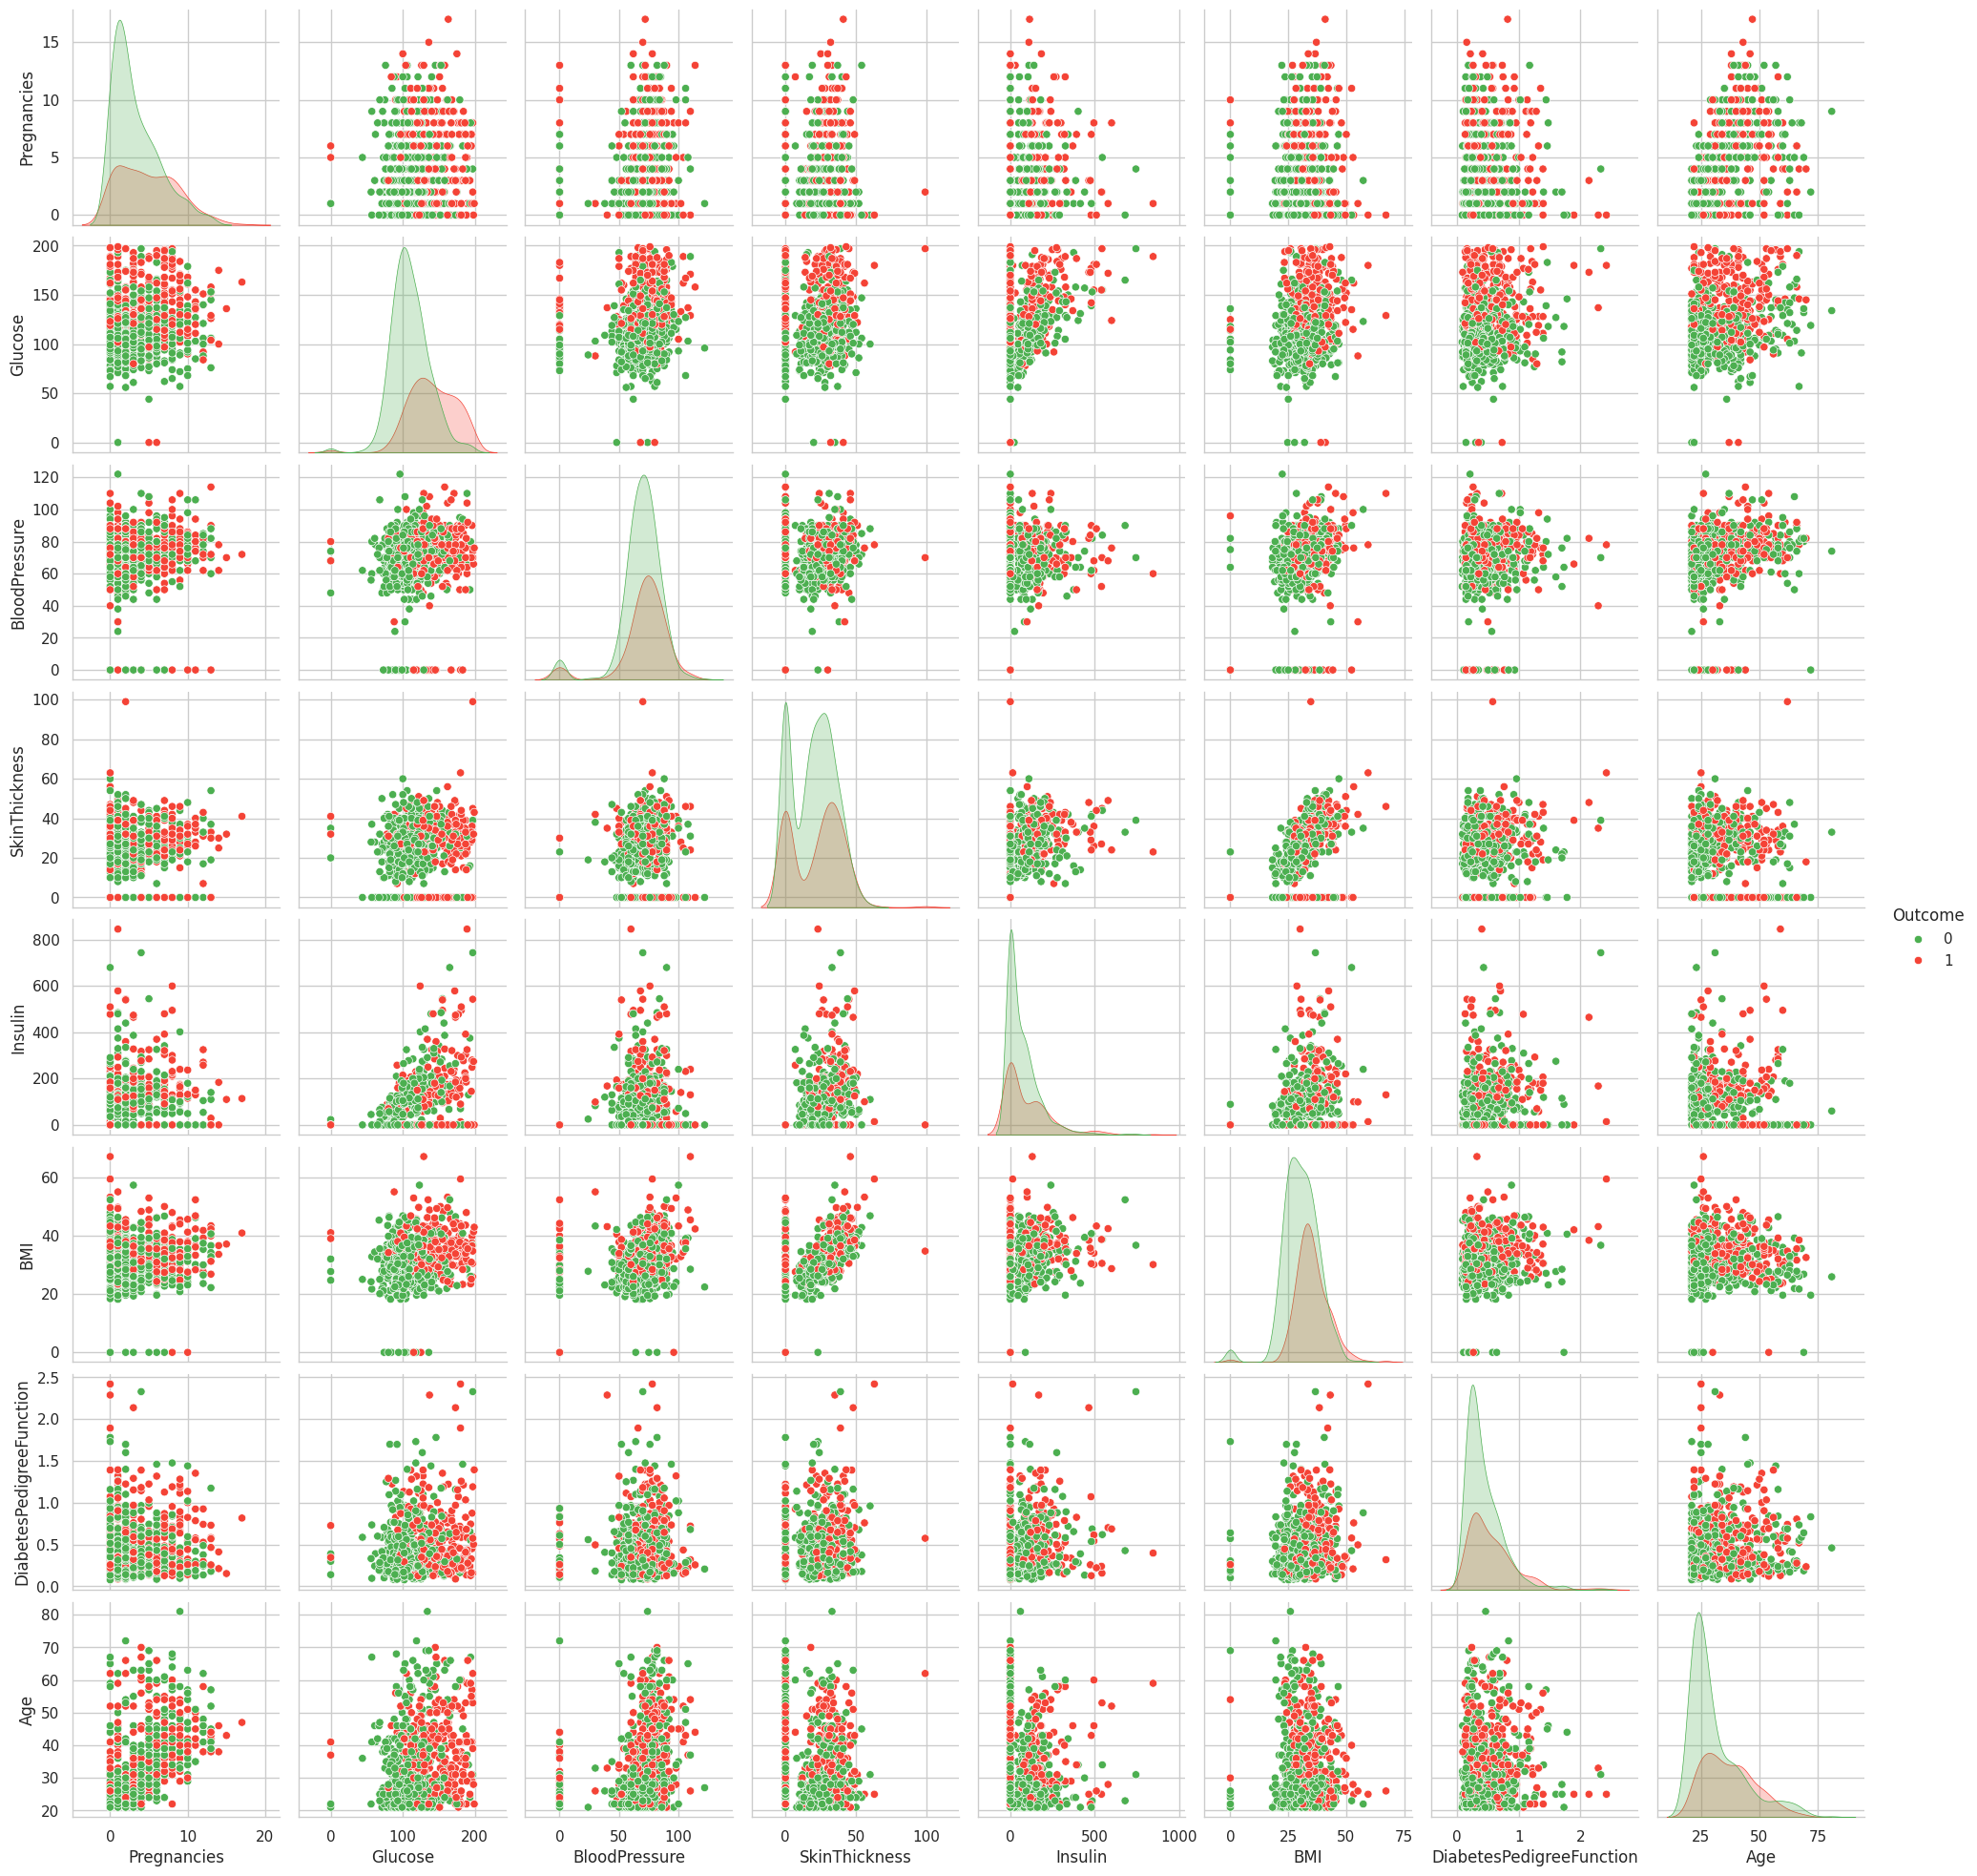

In [ ]:
# Pair Plot
sns.pairplot(df, hue='Outcome', palette=['#4CAF50', '#F44336'])

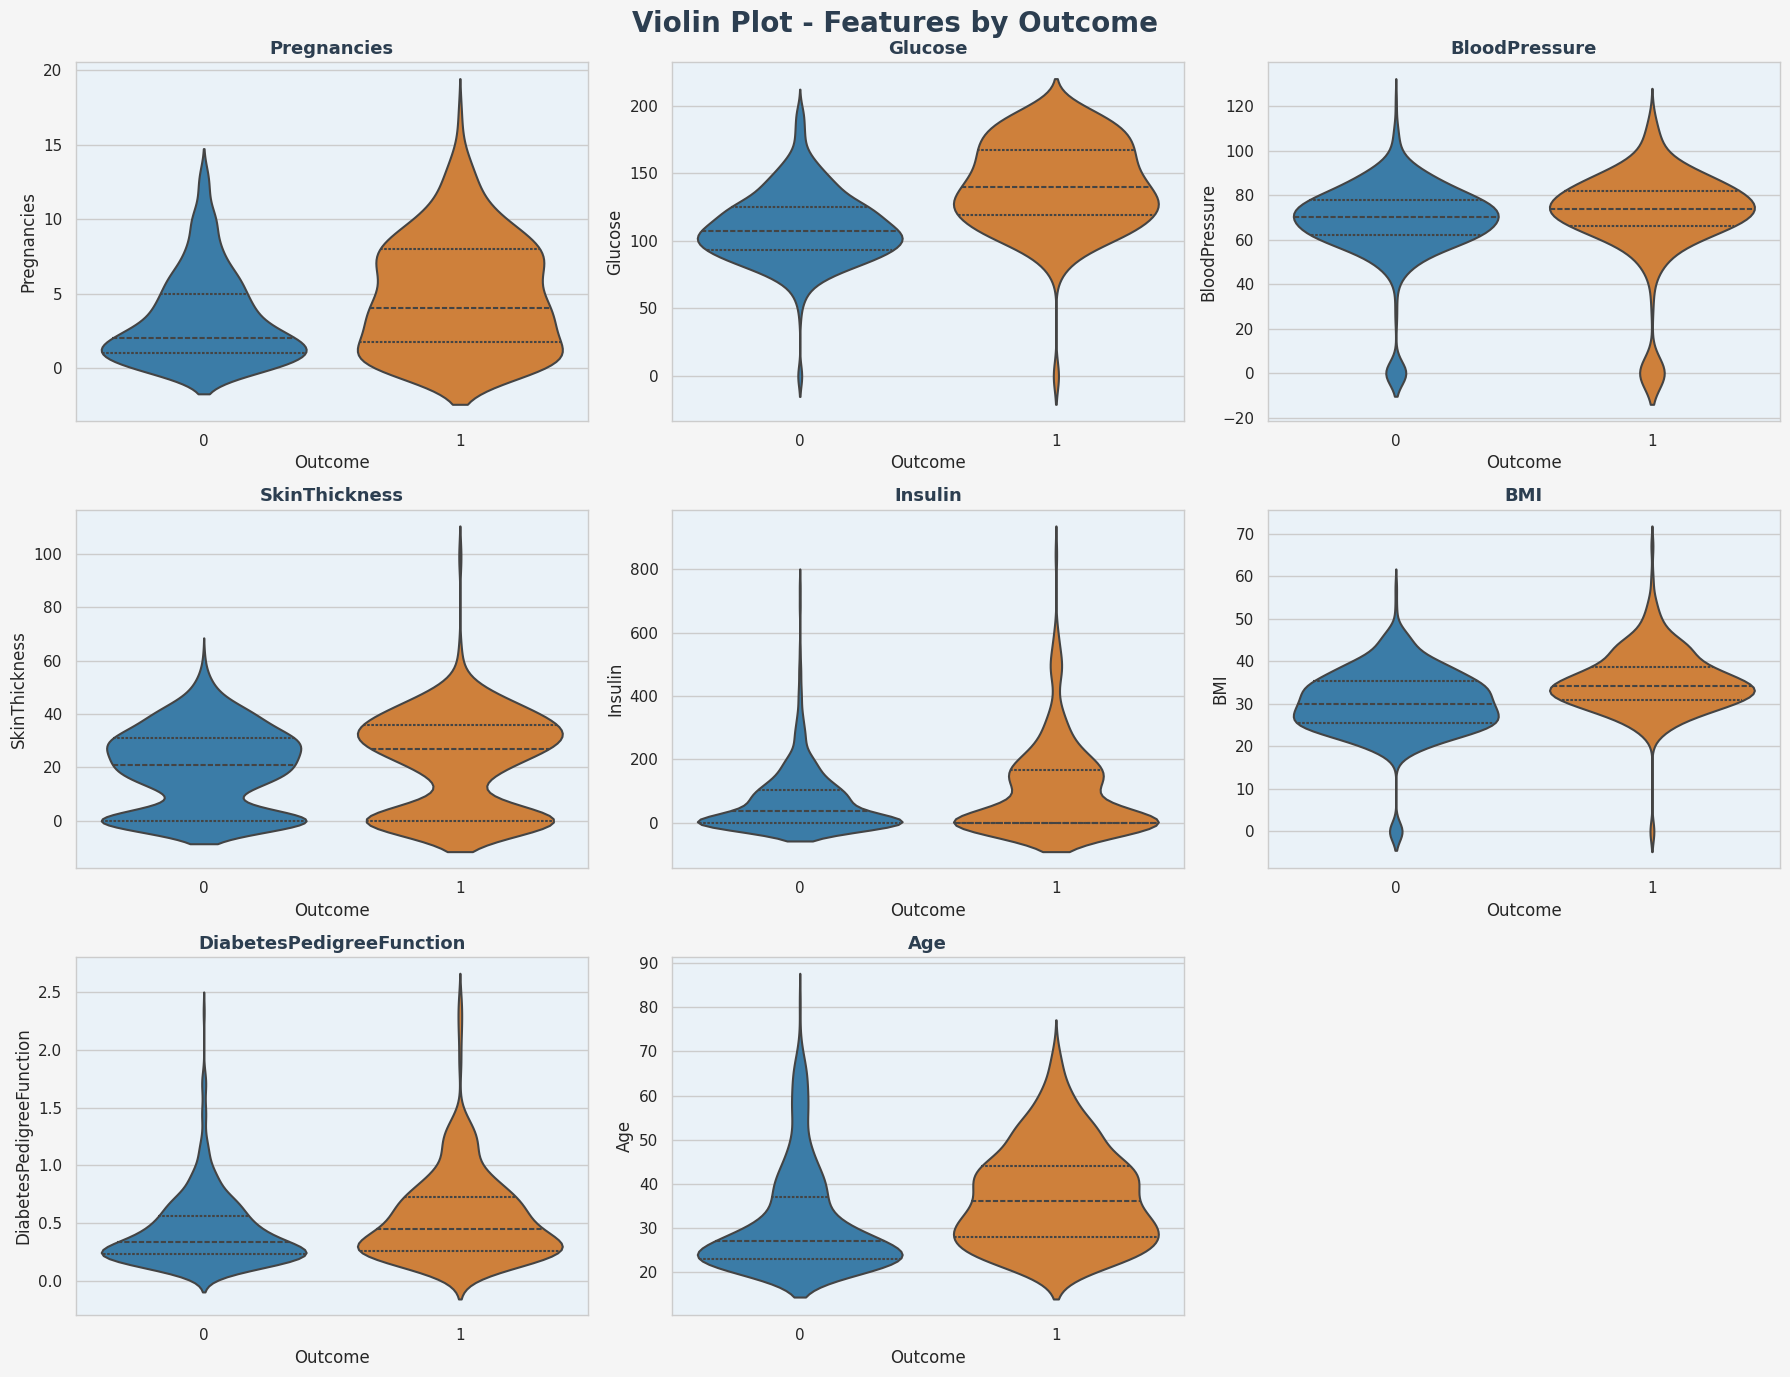

In [ ]:
# Violin Plot
fig, axes = plt.subplots((len(num_cols)//3)+1, 3, figsize=(18, 14), facecolor='#F5F5F5')
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.violinplot(x='Outcome', y=col, data=df, ax=axes[i],
                   palette=['#2980B9', '#E67E22'], inner='quartile', linewidth=1.5)
    axes[i].set_title(col, fontsize=13, fontweight='bold', color='#2C3E50')
    axes[i].set_facecolor('#EAF2F8')

for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Violin Plot - Features by Outcome', fontsize=20, fontweight='bold', color='#2C3E50')
plt.tight_layout()
plt.show()

In [ ]:
# density graph
fig, ax = plt.subplots(4, 2, figsize=(20, 20))
cols = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness',
        'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']
for a, col in zip(ax.flat, cols):
    sns.histplot(df[col], bins=20, kde=True, ax=a, color='red')
    a.set_title(col)
plt.tight_layout()


In [ ]:
df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

In [ ]:
df.groupby("Outcome").agg({'Pregnancies':'mean'})

,Pregnancies
Outcome,
0,3.298000
1,4.865672


In [ ]:
df.groupby("Outcome").agg({'Pregnancies':'max'})

,Pregnancies
Outcome,
0,13
1,17


In [ ]:
df.groupby("Outcome").agg({'Glucose':'mean'})

,Glucose
Outcome,
0,109.980000
1,141.257463


In [ ]:
df.groupby("Outcome").agg({'Glucose':'max'})

,Glucose
Outcome,
0,197
1,199


In [ ]:
# Homework
# 'BloodPressure', 'SkinThickness', 'Insulin',
#        'BMI', 'DiabetesPedigreeFunction', 'Age'
#     groupby-> mean/max

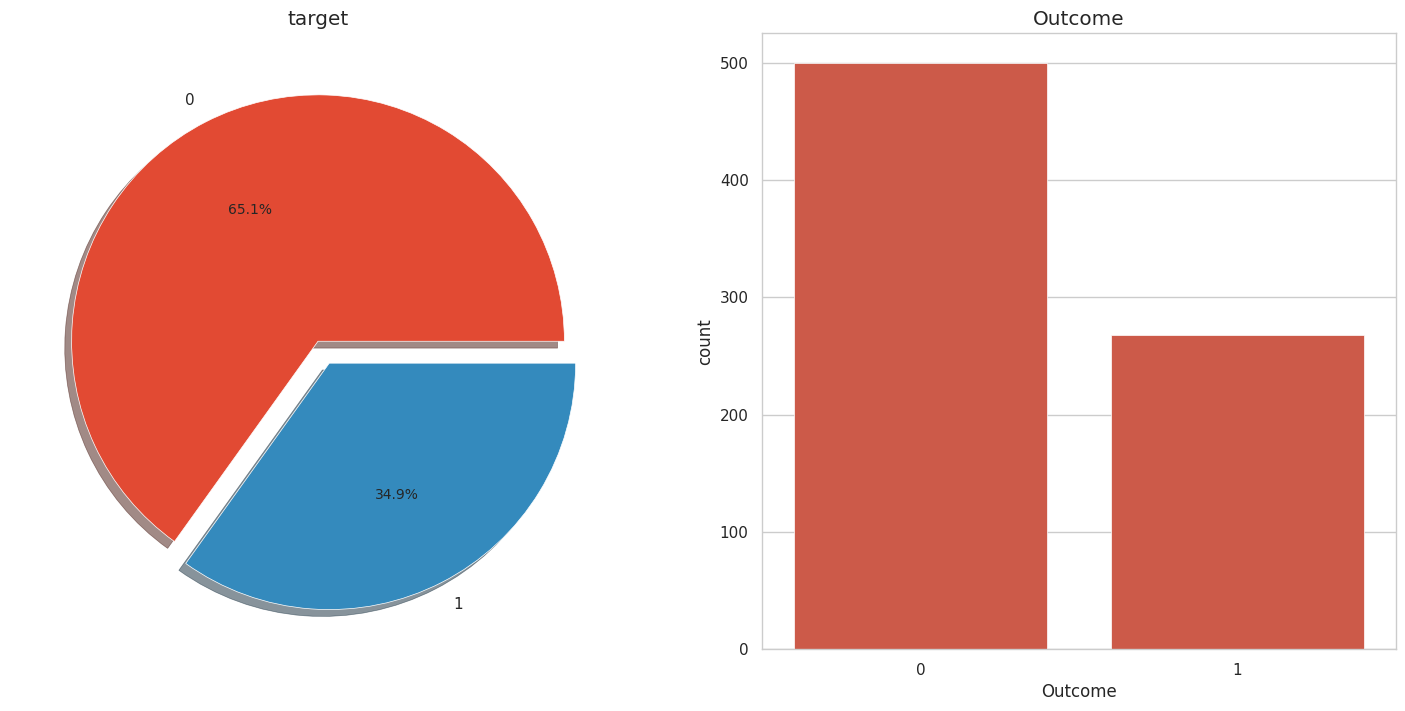

In [ ]:
# 0>healthy
# 1>diabetes

f,ax = plt.subplots(1,2, figsize=(18,8))
df['Outcome'].value_counts().plot.pie(explode=[0,0.1],autopct = "%1.1f%%", ax=ax[0], shadow=True)
ax[0].set_title('target')
ax[0].set_ylabel('')
sns.countplot(x ='Outcome', data=df, ax=ax[1])
ax[1].set_title('Outcome')
plt.show()

In [ ]:
df.corr()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
Pregnancies,1.000000,0.129459,0.141282,-0.081672,-0.073535,0.017683,-0.033523,0.544341,0.221898
Glucose,0.129459,1.000000,0.152590,0.057328,0.331357,0.221071,0.137337,0.263514,0.466581
BloodPressure,0.141282,0.152590,1.000000,0.207371,0.088933,0.281805,0.041265,0.239528,0.065068
SkinThickness,-0.081672,0.057328,0.207371,1.000000,0.436783,0.392573,0.183928,-0.113970,0.074752
Insulin,-0.073535,0.331357,0.088933,0.436783,1.000000,0.197859,0.185071,-0.042163,0.130548
BMI,0.017683,0.221071,0.281805,0.392573,0.197859,1.000000,0.140647,0.036242,0.292695
DiabetesPedigreeFunction,-0.033523,0.137337,0.041265,0.183928,0.185071,0.140647,1.000000,0.033561,0.173844
Age,0.544341,0.263514,0.239528,-0.113970,-0.042163,0.036242,0.033561,1.000000,0.238356
Outcome,0.221898,0.466581,0.065068,0.074752,0.130548,0.292695,0.173844,0.238356,1.000000


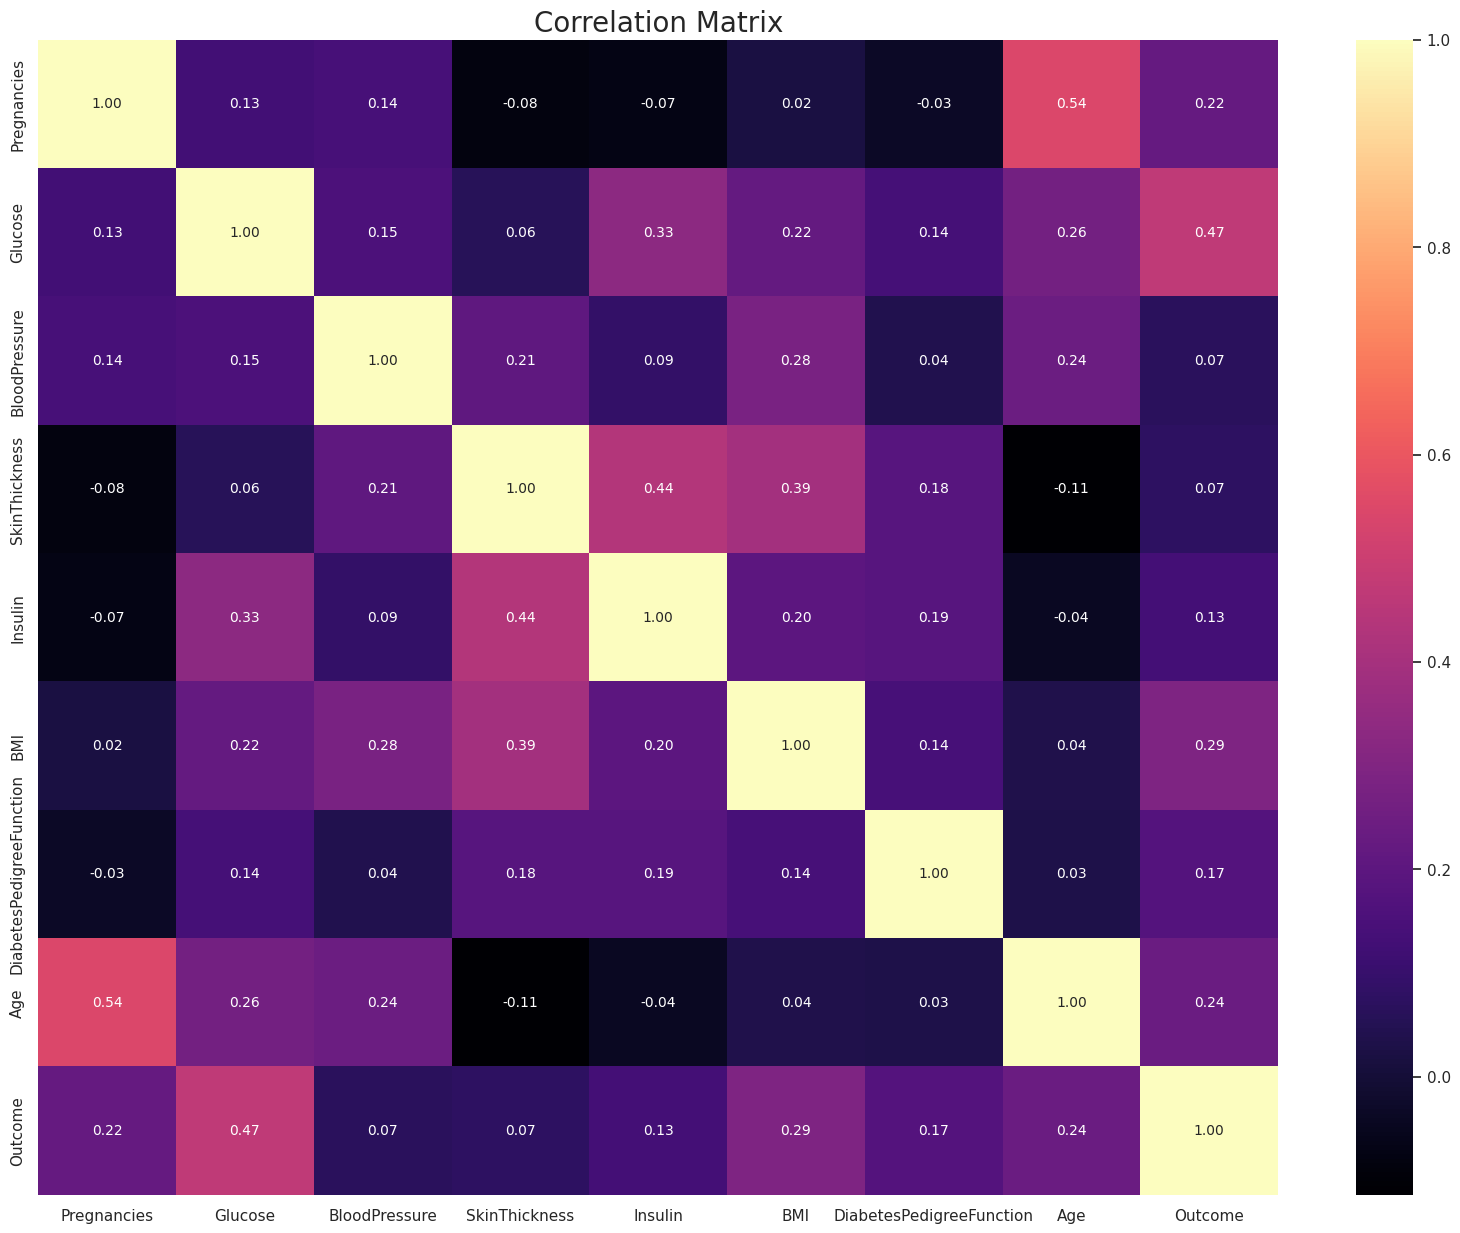

In [ ]:
f,ax = plt.subplots(figsize=[20,15])
sns.heatmap(df.corr(), annot=True, fmt = '.2f', ax=ax, cmap='magma')
ax.set_title("Correlation Matrix", fontsize=20)
plt.show()

In [ ]:
# EDA Part Completed
df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

In [ ]:
df[['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age']] = df[['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age']].replace(0, np.nan)

# Data preprocessing Part

In [ ]:

df.isnull().sum()

,0
Pregnancies,0
Glucose,5
BloodPressure,35
SkinThickness,227
Insulin,374
BMI,11
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [ ]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148.0,72.0,35.0,NaN,33.6,0.627,50,1
1,1,85.0,66.0,29.0,NaN,26.6,0.351,31,0
2,8,183.0,64.0,NaN,NaN,23.3,0.672,32,1
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1


In [ ]:
# Missing-value bar chart (pandas)
df.notna().sum().plot.bar(color="orange", figsize=(10, 4))
plt.ylabel("Non-null count"); plt.title("Missing values per column")
plt.tight_layout(); plt.show()


In [ ]:
#median
def median_target(var):
    temp = df[df[var].notnull()]
    temp = temp[[var, 'Outcome']].groupby(['Outcome'])[[var]].median().reset_index()
    return temp

In [ ]:
columns = df.columns
columns = columns.drop("Outcome")
for i in columns:
    median_target(i)
    df.loc[(df['Outcome'] == 0 ) & (df[i].isnull()), i] = median_target(i)[i][0]
    df.loc[(df['Outcome'] == 1 ) & (df[i].isnull()), i] = median_target(i)[i][1]

In [ ]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148.0,72.0,35.0,169.5,33.6,0.627,50,1
1,1,85.0,66.0,29.0,102.5,26.6,0.351,31,0
2,8,183.0,64.0,32.0,169.5,23.3,0.672,32,1
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1


In [ ]:

df.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


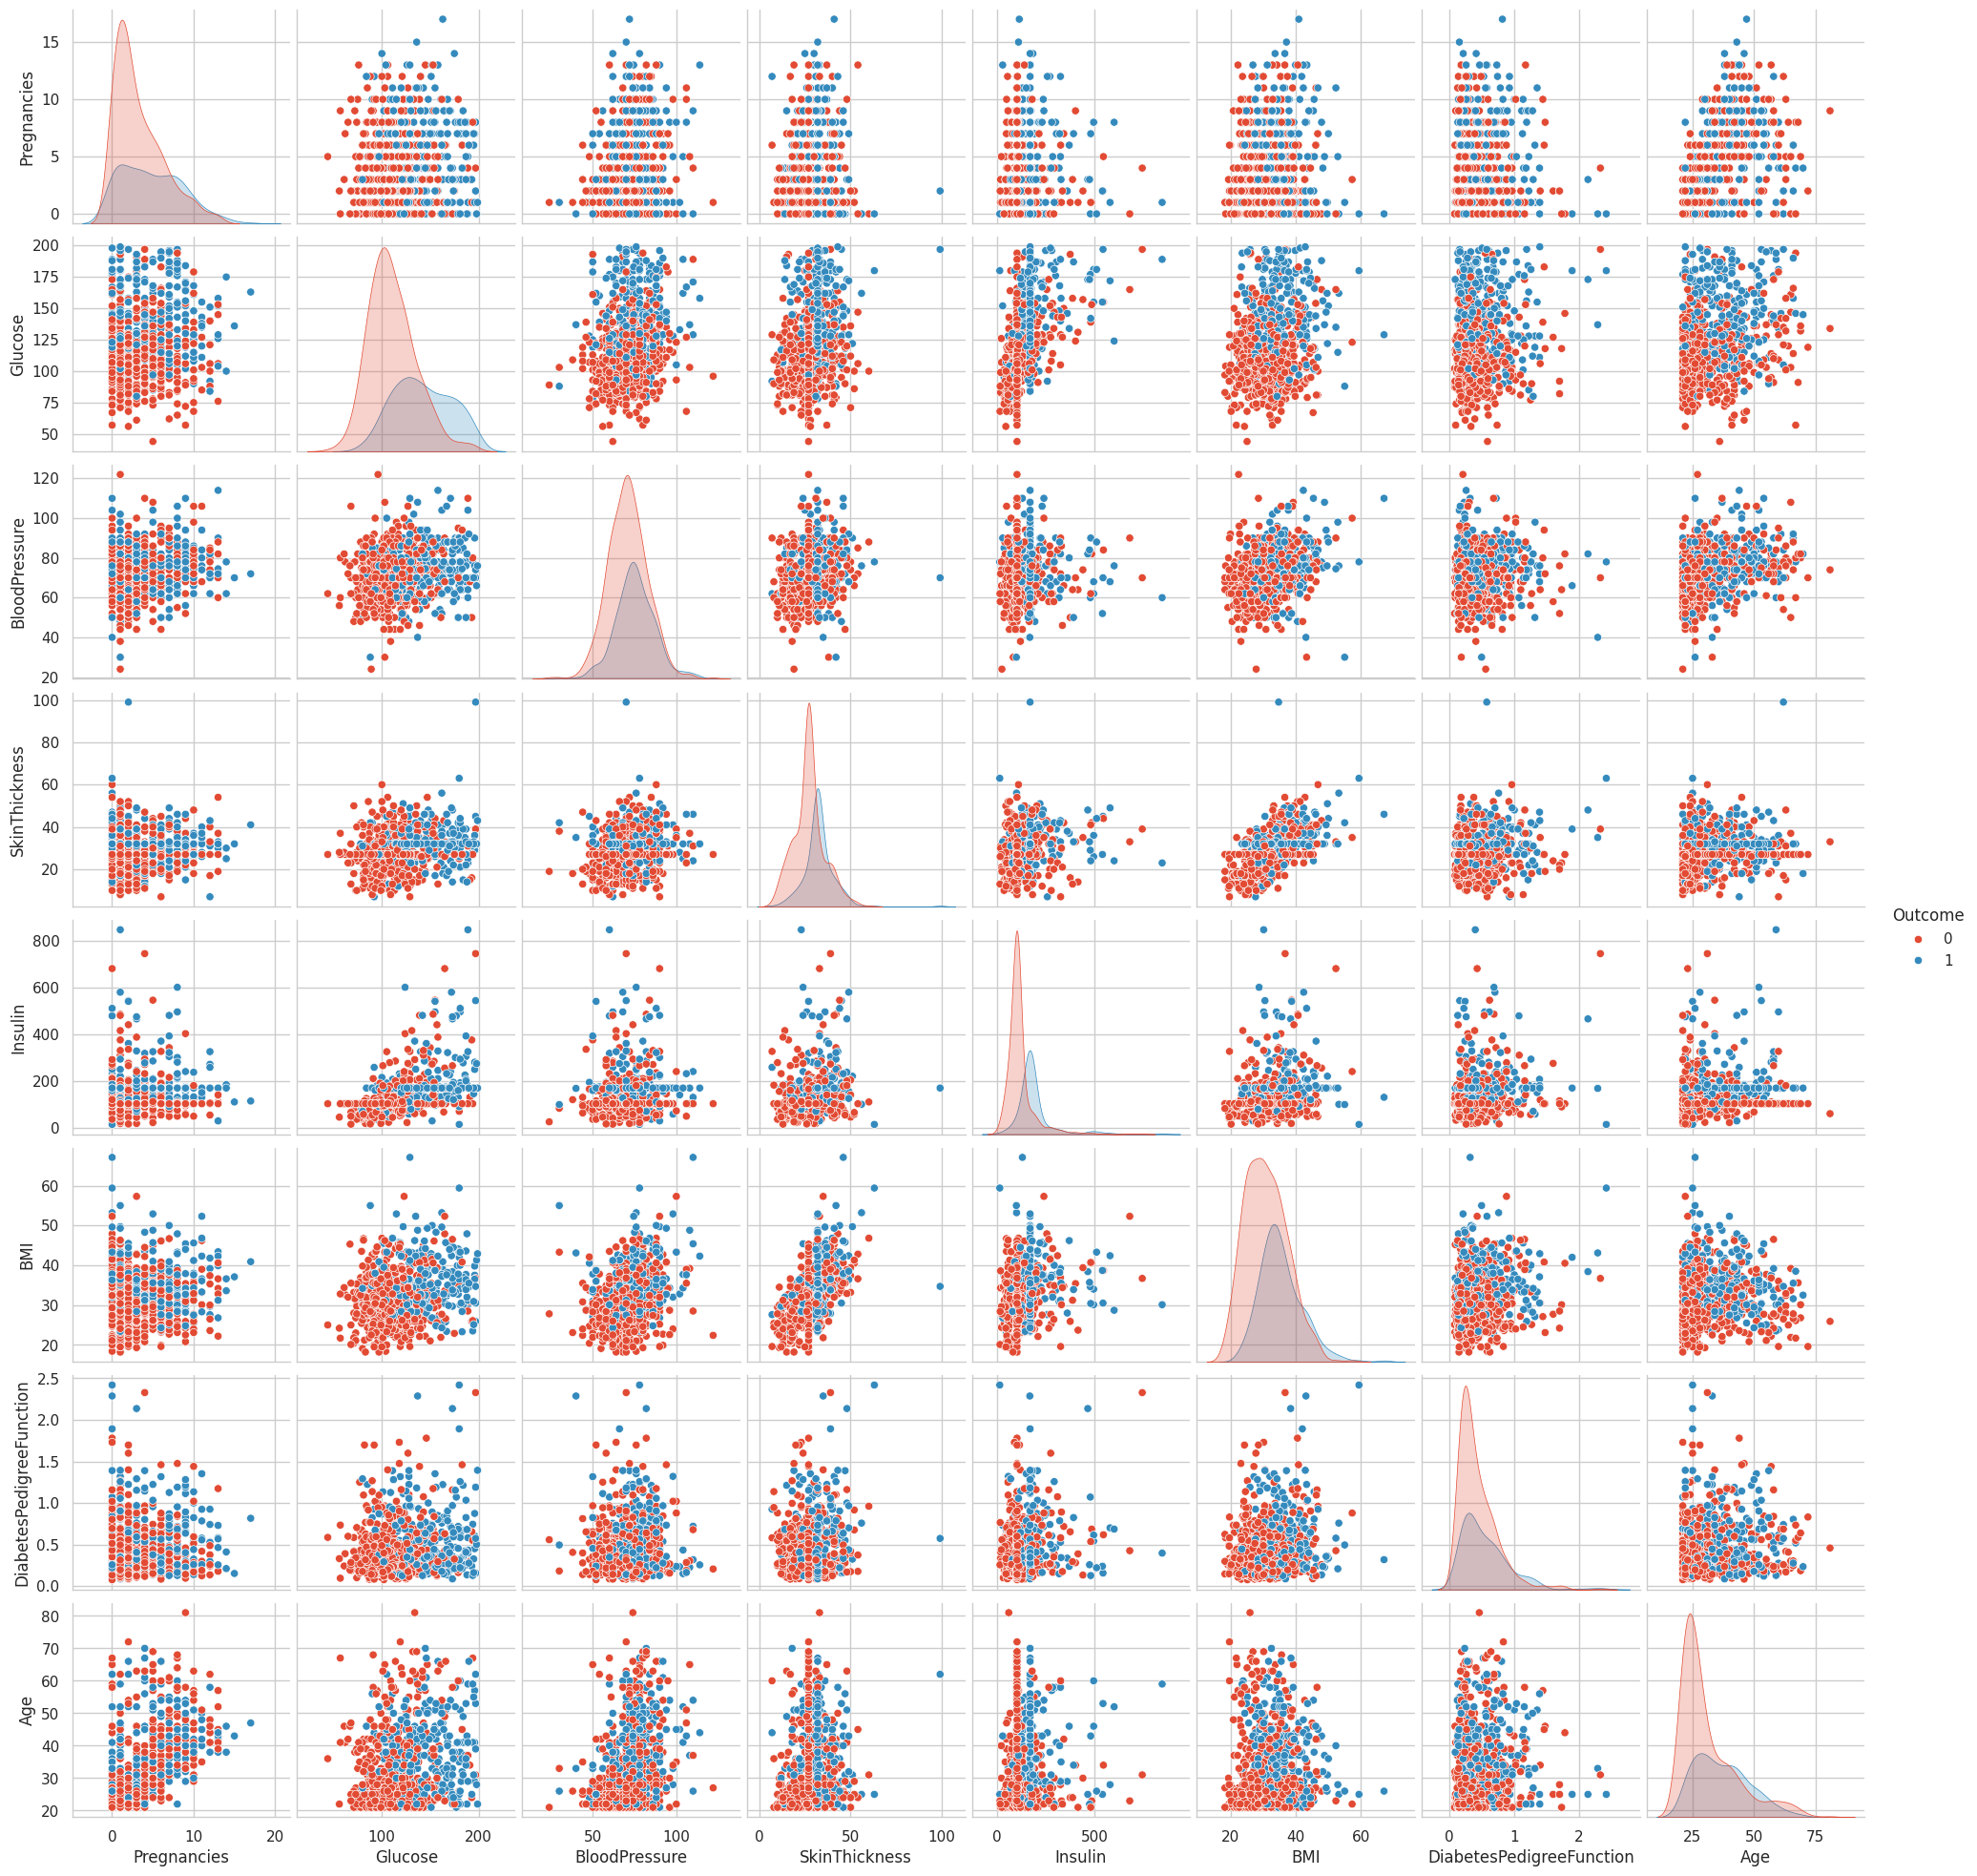

In [ ]:
# pair plot
p = sns.pairplot(df, hue="Outcome")

In [ ]:
# # Outlier Detection
# # IQR+Q1
# # 50%
# # 24.65->25%+50%
# # 24.65->25%
# for feature in df:
#     Q1 = df[feature].quantile(0.25)
#     Q3 = df[feature].quantile(0.75)
#     IQR = Q3-Q1
#     lower = Q1-1.5*IQR
#     upper = Q3+1.5*IQR
#     if df[(df[feature]>upper)].any(axis=None):
#         print(feature, "yes")
#     else:
#         print(feature, "no")

In [ ]:
# plt.figure(figsize=(8,7))
# sns.boxplot(x= df["Insulin"], color="red")

In [ ]:
# Q1 = df.Insulin.quantile(0.25)
# Q3 = df.Insulin.quantile(0.75)
# IQR = Q3-Q1
# lower = Q1-1.5*IQR
# upper = Q3+1.5*IQR
# df.loc[df['Insulin']>upper, "Insulin"] = upper

In [ ]:
# plt.figure(figsize=(8,7))
# sns.boxplot(x= df["Insulin"], color="red")

In [ ]:
# # LOF
# # local outlier factor
# from sklearn.neighbors import LocalOutlierFactor
# lof = LocalOutlierFactor(n_neighbors=10)
# lof.fit_predict(df)

In [ ]:
# df.head()

In [ ]:
# plt.figure(figsize=(8,7))
# sns.boxplot(x= df["Pregnancies"], color="red")

In [ ]:
# df_scores = lof.negative_outlier_factor_
# np.sort(df_scores)[0:20]

In [ ]:
# thresold = np.sort(df_scores)[7]

In [ ]:
# thresold

In [ ]:
# outlier = df_scores>thresold

In [ ]:
# df = df[outlier]

In [ ]:
# df.head()

In [ ]:
# df.shape

In [ ]:
# plt.figure(figsize=(8,7))
# sns.boxplot(x= df["Pregnancies"], color="red")

In [ ]:
# Outlier Detection



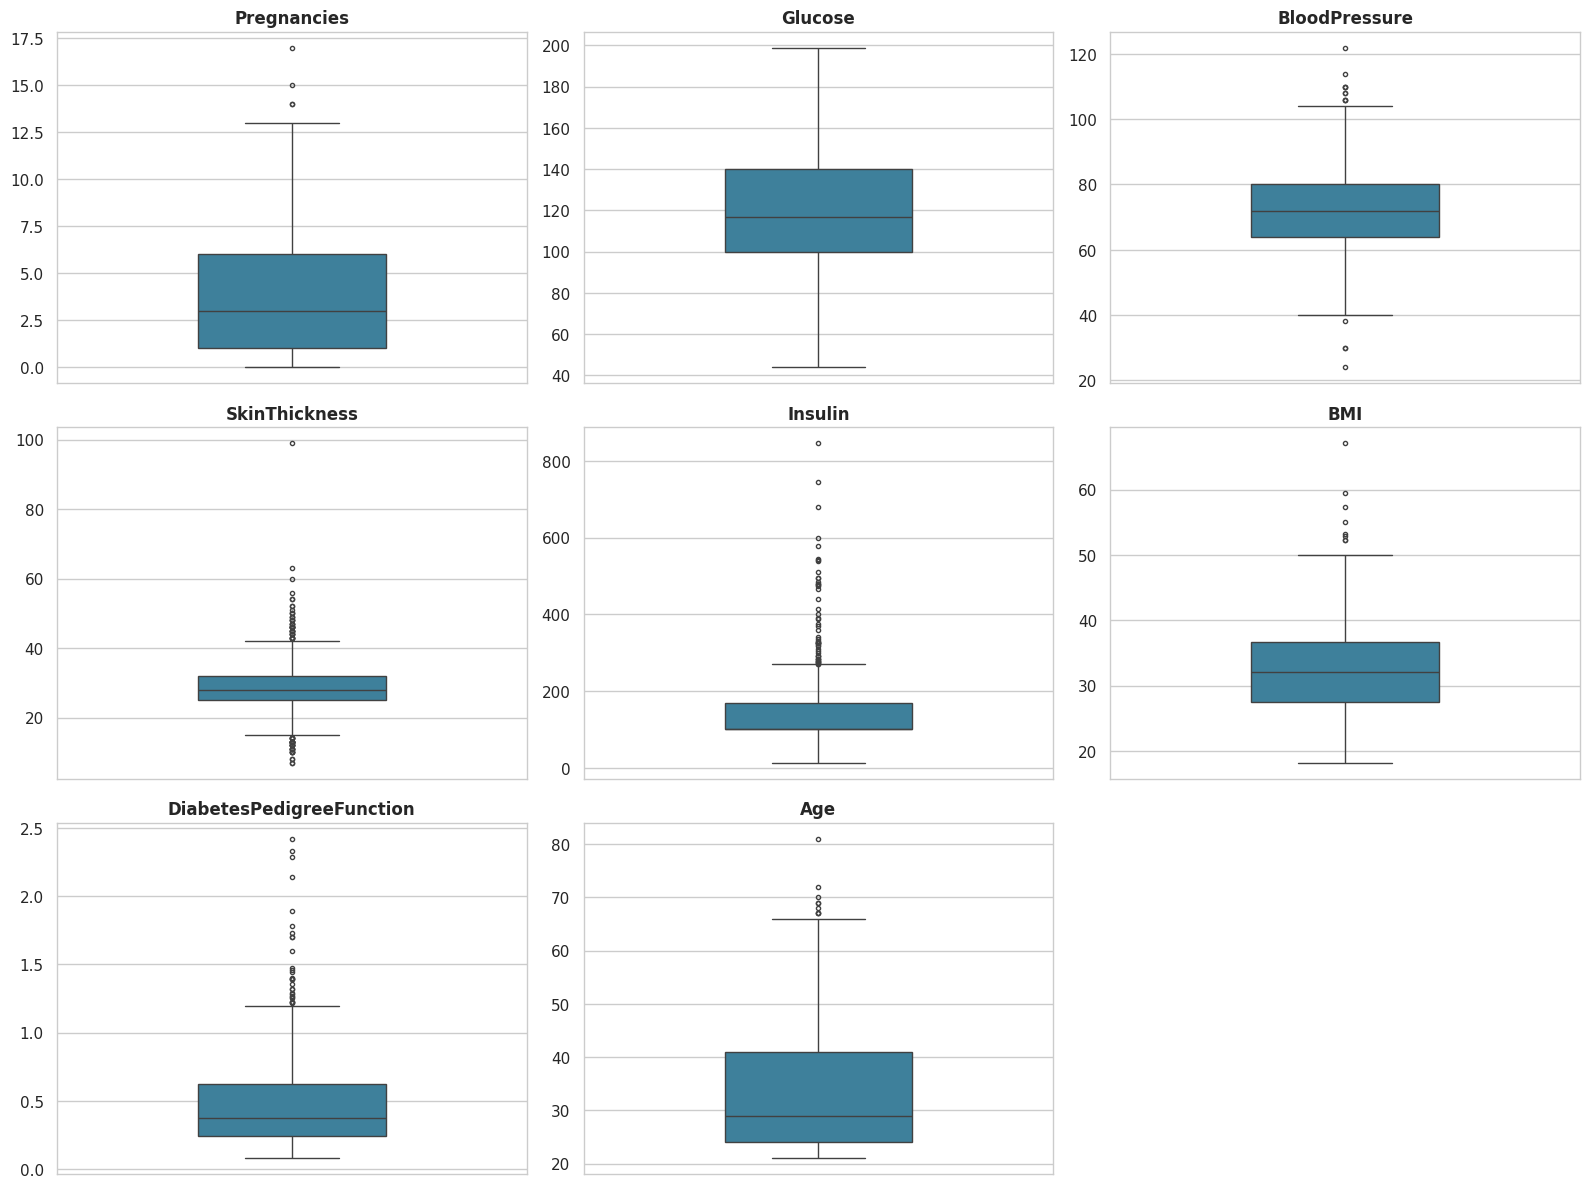

In [ ]:
# Outlier detection
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (16, 12)

# Exclude Outcome
num_cols = [col for col in df.select_dtypes(include=['int64', 'float64']).columns if col != 'Outcome']

rows = (len(num_cols) // 3) + 1
fig, axes = plt.subplots(rows, 3)
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(
        y=df[col],
        ax=axes[i],
        color="#2E86AB",
        width=0.4,
        fliersize=3 )

    axes[i].set_title(col, fontsize=12, fontweight='bold')
    axes[i].set_xlabel("")
    axes[i].set_ylabel("")

for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

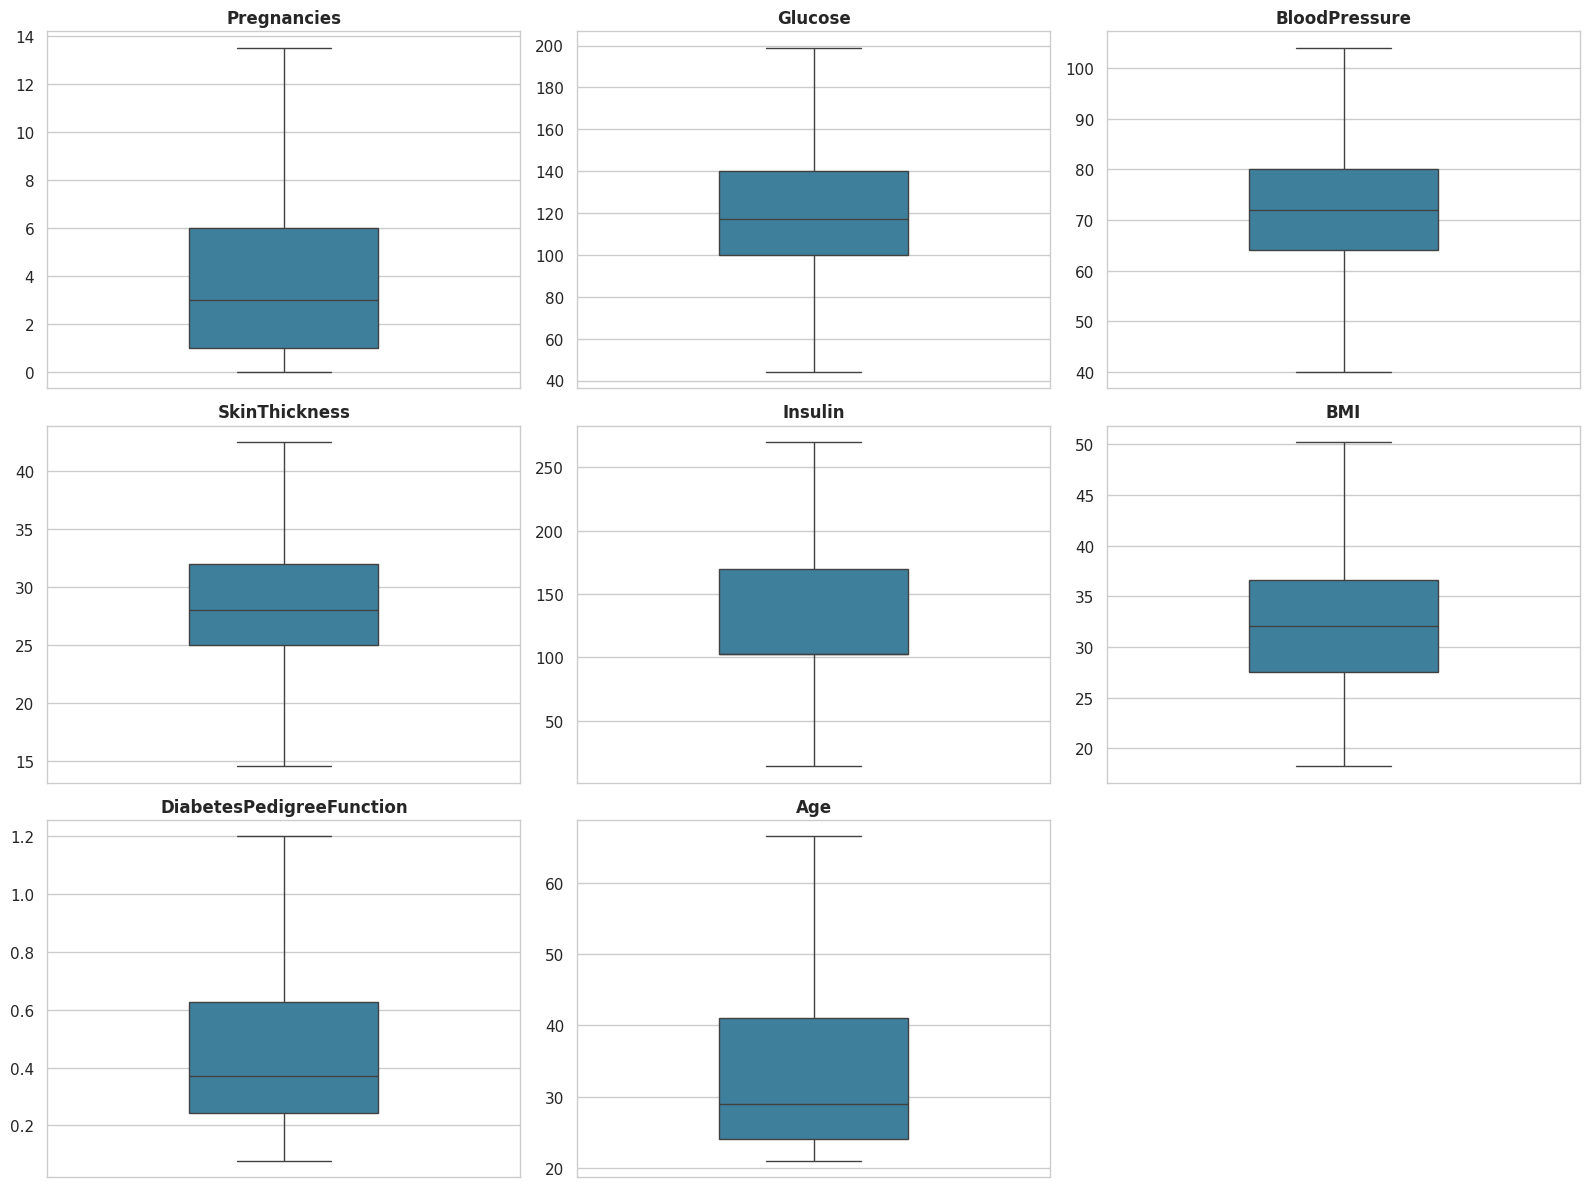

In [ ]:
# Outlier Handling
import numpy as np

# Exclude Outcome
num_cols = [col for col in df.select_dtypes(include=['int64', 'float64']).columns if col != 'Outcome']
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    # Clip values instead of removing
    df[col] = df[col].clip(lower, upper)


# After Handling Outliers

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (16, 12)

rows = (len(num_cols) // 3) + 1
fig, axes = plt.subplots(rows, 3)
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(
        y=df[col],
        ax=axes[i],
        color="#2E86AB",
        width=0.4,
        fliersize=3
    )

    axes[i].set_title(col, fontsize=12, fontweight='bold')
    axes[i].set_xlabel("")
    axes[i].set_ylabel("")

# Remove empty plots
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


# Feature Engineering

In [ ]:
# Feature Enginnering
NewBMI = pd.Series(["Underweight","Normal", "Overweight","Obesity 1", "Obesity 2", "Obesity 3"], dtype = "category")

In [ ]:
NewBMI

,0
0,Underweight
1,Normal
2,Overweight
3,Obesity 1
4,Obesity 2
5,Obesity 3


In [ ]:
df['NewBMI'] = pd.cut(
    df['BMI'],
    bins=[-np.inf, 18.5, 24.9, 29.9, 34.9, 39.9, np.inf],
    labels=['Underweight', 'Normal', 'Overweight', 'Obesity 1', 'Obesity 2', 'Obesity 3'],
)


In [ ]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,NewBMI
0,6.0,148.0,72.0,35.0,169.5,33.6,0.627,50.0,1,Obesity 1
1,1.0,85.0,66.0,29.0,102.5,26.6,0.351,31.0,0,Overweight
2,8.0,183.0,64.0,32.0,169.5,23.3,0.672,32.0,1,Normal
3,1.0,89.0,66.0,23.0,94.0,28.1,0.167,21.0,0,Overweight
4,0.0,137.0,40.0,35.0,168.0,43.1,1.200,33.0,1,Obesity 3


In [ ]:
# Normal insulin range: 16-166 (inclusive)
df['NewInsulinScore'] = np.where(df['Insulin'].between(16, 166), 'Normal', 'Abnormal')


In [ ]:
df.head()


In [ ]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,NewBMI,NewInsulinScore
0,6.0,148.0,72.0,35.0,169.5,33.6,0.627,50.0,1,Obesity 1,Abnormal
1,1.0,85.0,66.0,29.0,102.5,26.6,0.351,31.0,0,Overweight,Normal
2,8.0,183.0,64.0,32.0,169.5,23.3,0.672,32.0,1,Normal,Abnormal
3,1.0,89.0,66.0,23.0,94.0,28.1,0.167,21.0,0,Overweight,Normal
4,0.0,137.0,40.0,35.0,168.0,43.1,1.200,33.0,1,Obesity 3,Abnormal


In [ ]:
df['NewGlucose'] = pd.cut(
    df['Glucose'],
    bins=[-np.inf, 70, 99, 126, 200, np.inf],
    labels=['Low', 'Normal', 'Overweight', 'Secret', 'High'],
)


In [ ]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,NewBMI,NewInsulinScore,NewGlucose
0,6.0,148.0,72.0,35.0,169.5,33.6,0.627,50.0,1,Obesity 1,Abnormal,Secret
1,1.0,85.0,66.0,29.0,102.5,26.6,0.351,31.0,0,Overweight,Normal,Normal
2,8.0,183.0,64.0,32.0,169.5,23.3,0.672,32.0,1,Normal,Abnormal,Secret
3,1.0,89.0,66.0,23.0,94.0,28.1,0.167,21.0,0,Overweight,Normal,Normal
4,0.0,137.0,40.0,35.0,168.0,43.1,1.200,33.0,1,Obesity 3,Abnormal,Secret


In [ ]:
# One hot encoding
df = pd.get_dummies(df, columns = ["NewBMI", "NewInsulinScore", "NewGlucose"], drop_first=True,dtype = int)

In [ ]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,NewBMI_Obesity 1,NewBMI_Obesity 2,NewBMI_Obesity 3,NewBMI_Overweight,NewBMI_Underweight,NewInsulinScore_Normal,NewGlucose_Normal,NewGlucose_Overweight,NewGlucose_Secret
0,6.0,148.0,72.0,35.0,169.5,33.6,0.627,50.0,1,1,0,0,0,0,0,0,0,1
1,1.0,85.0,66.0,29.0,102.5,26.6,0.351,31.0,0,0,0,0,1,0,1,1,0,0
2,8.0,183.0,64.0,32.0,169.5,23.3,0.672,32.0,1,0,0,0,0,0,0,0,0,1
3,1.0,89.0,66.0,23.0,94.0,28.1,0.167,21.0,0,0,0,0,1,0,1,1,0,0
4,0.0,137.0,40.0,35.0,168.0,43.1,1.200,33.0,1,0,0,1,0,0,0,0,0,1


In [ ]:
df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome', 'NewBMI_Obesity 1',
       'NewBMI_Obesity 2', 'NewBMI_Obesity 3', 'NewBMI_Overweight',
       'NewBMI_Underweight', 'NewInsulinScore_Normal', 'NewGlucose_Normal',
       'NewGlucose_Overweight', 'NewGlucose_Secret'],
      dtype='object')

In [ ]:
categorical_df = df[[col for col in df.columns
                      if col.startswith('NewBMI_')
                      or col.startswith('NewInsulinScore_')
                      or col.startswith('NewGlucose_')]]

In [ ]:
categorical_df.head()

,NewBMI_Obesity 1,NewBMI_Obesity 2,NewBMI_Obesity 3,NewBMI_Overweight,NewBMI_Underweight,NewInsulinScore_Normal,NewGlucose_Normal,NewGlucose_Overweight,NewGlucose_Secret
0,1,0,0,0,0,0,0,0,1
1,0,0,0,1,0,1,1,0,0
2,0,0,0,0,0,0,0,0,1
3,0,0,0,1,0,1,1,0,0
4,0,0,1,0,0,0,0,0,1


In [ ]:
y = df['Outcome']
X = df.drop(['Outcome'] + categorical_df.columns.tolist(), axis=1)

In [ ]:
cols = X.columns
index = X.index

In [ ]:
X.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,6.0,148.0,72.0,35.0,169.5,33.6,0.627,50.0
1,1.0,85.0,66.0,29.0,102.5,26.6,0.351,31.0
2,8.0,183.0,64.0,32.0,169.5,23.3,0.672,32.0
3,1.0,89.0,66.0,23.0,94.0,28.1,0.167,21.0
4,0.0,137.0,40.0,35.0,168.0,43.1,1.200,33.0


# Buliding Model

In [ ]:
# RobustScaler removed to avoid double-scaling (StandardScaler applied in train/test split cell)
# transformer = RobustScaler().fit(X)
# X=transformer.transform(X)
# X=pd.DataFrame(X, columns = cols, index = index)

In [ ]:
X.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,6.0,148.0,72.0,35.0,169.5,33.6,0.627,50.0
1,1.0,85.0,66.0,29.0,102.5,26.6,0.351,31.0
2,8.0,183.0,64.0,32.0,169.5,23.3,0.672,32.0
3,1.0,89.0,66.0,23.0,94.0,28.1,0.167,21.0
4,0.0,137.0,40.0,35.0,168.0,43.1,1.200,33.0


In [ ]:
X = pd.concat([X, categorical_df], axis=1)

In [ ]:
all_feature_names = X.columns.tolist()
X.head()


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,NewBMI_Obesity 1,NewBMI_Obesity 2,NewBMI_Obesity 3,NewBMI_Overweight,NewBMI_Underweight,NewInsulinScore_Normal,NewGlucose_Normal,NewGlucose_Overweight,NewGlucose_Secret
0,6.0,148.0,72.0,35.0,169.5,33.6,0.627,50.0,1,0,0,0,0,0,0,0,1
1,1.0,85.0,66.0,29.0,102.5,26.6,0.351,31.0,0,0,0,1,0,1,1,0,0
2,8.0,183.0,64.0,32.0,169.5,23.3,0.672,32.0,0,0,0,0,0,0,0,0,1
3,1.0,89.0,66.0,23.0,94.0,28.1,0.167,21.0,0,0,0,1,0,1,1,0,0
4,0.0,137.0,40.0,35.0,168.0,43.1,1.200,33.0,0,0,1,0,0,0,0,0,1


In [ ]:
X_train, X_test, y_train , y_test = train_test_split(X,y, test_size=0.2, random_state=0)

In [ ]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Handle class imbalance
print(f"Before SMOTE: X_train={X_train.shape}, class counts={np.bincount(y_train)}")
X_train, y_train = SMOTE(k_neighbors=5, random_state=42).fit_resample(X_train, y_train)
print(f"After  SMOTE: X_train={X_train.shape}, class counts={np.bincount(y_train)}")


In [ ]:
pd.DataFrame(X_train, columns=X.columns)  # to view training data

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,NewBMI_Obesity 1,NewBMI_Obesity 2,NewBMI_Obesity 3,NewBMI_Overweight,NewBMI_Underweight,NewInsulinScore_Normal,NewGlucose_Normal,NewGlucose_Overweight,NewGlucose_Secret
0,0.919464,0.934964,0.466544,0.014777,-0.139328,0.395043,0.843251,1.726840,-0.661770,1.948557,-0.381474,-0.528362,-0.057166,0.755204,-0.563557,-0.757865,1.269947
1,0.039644,-0.816049,-1.085372,-0.785797,-0.541802,-0.641681,-0.035169,-0.974402,-0.661770,-0.513200,-0.381474,1.892641,-0.057166,0.755204,1.774443,-0.757865,-0.787434
2,-1.133448,1.430533,1.501154,0.548493,2.326897,2.624000,-0.091613,-0.889988,-0.661770,-0.513200,2.621411,-0.528362,-0.057166,-1.324146,-0.563557,-0.757865,1.269947
3,-0.840175,-0.419593,-1.430243,-1.052655,0.014811,-1.085991,1.340669,-0.889988,-0.661770,-0.513200,-0.381474,1.892641,-0.057166,0.755204,-0.563557,1.319497,-0.787434
4,1.212737,-0.056175,0.164782,0.415064,0.605678,-0.375095,-0.952394,0.376219,1.511100,-0.513200,-0.381474,-0.528362,-0.057166,-1.324146,-0.563557,1.319497,-0.787434
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
781,1.690737,1.272717,0.057745,0.335983,0.605678,0.033021,-0.276664,0.792008,1.511100,-0.513200,-0.381474,-0.528362,-0.057166,-1.324146,-0.563557,-0.757865,1.269947
782,2.478083,0.925817,0.051444,1.046509,0.105867,1.895853,0.884429,0.855755,-0.661770,-0.513200,2.621411,-0.528362,-0.057166,-0.230770,-0.563557,-0.757865,1.269947
783,1.655822,0.810707,0.966979,1.679003,1.648620,0.772226,1.917806,1.357978,-0.661770,1.948557,-0.381474,-0.528362,-0.057166,-1.324146,-0.563557,-0.757865,1.269947
784,1.078394,-0.933620,0.688593,0.087085,0.605678,0.401579,0.537207,1.729670,0.442883,0.697039,-0.381474,-0.528362,-0.057166,-1.324146,1.774443,-0.757865,-0.787434


In [ ]:
pd.DataFrame(X_test, columns=X.columns)   # to view test data

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,NewBMI_Obesity 1,NewBMI_Obesity 2,NewBMI_Obesity 3,NewBMI_Overweight,NewBMI_Underweight,NewInsulinScore_Normal,NewGlucose_Normal,NewGlucose_Overweight,NewGlucose_Secret
0,-0.840175,2.553824,0.294109,1.816069,0.605678,1.535440,2.635367,-0.974402,-0.66177,-0.5132,2.621411,-0.528362,-0.057166,-1.324146,-0.563557,-0.757865,1.269947
1,-0.546902,-0.485669,0.121673,0.148206,-0.584618,0.158078,-0.172752,-0.889988,1.51110,-0.5132,-0.381474,-0.528362,-0.057166,0.755204,-0.563557,1.319497,-0.787434
2,0.039644,-1.509846,-0.912937,-0.252081,-0.541802,0.217319,-0.218614,-0.721161,1.51110,-0.5132,-0.381474,-0.528362,-0.057166,0.755204,1.774443,-0.757865,-0.787434
3,0.332917,1.463571,-0.050762,-1.319513,0.699874,-0.997129,0.472833,1.473598,-0.66177,-0.5132,-0.381474,1.892641,-0.057166,-1.324146,-0.563557,-0.757865,1.269947
4,-1.133448,-0.353517,-0.654285,-0.252081,-0.541802,-1.174854,0.730361,-0.214678,-0.66177,-0.5132,-0.381474,-0.528362,-0.057166,0.755204,-0.563557,1.319497,-0.787434
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
149,-0.546902,-0.551745,0.638979,1.816069,0.973899,0.172888,0.910279,-0.383505,1.51110,-0.5132,-0.381474,-0.528362,-0.057166,-1.324146,-0.563557,1.319497,-0.787434
150,0.039644,-1.212504,-1.257807,-0.919226,-1.458073,-0.700923,-0.518476,-0.467919,-0.66177,-0.5132,-0.381474,1.892641,-0.057166,0.755204,1.774443,-0.757865,-0.787434
151,0.039644,0.670660,1.156284,0.415064,0.605678,1.698353,0.677445,-0.974402,-0.66177,-0.5132,2.621411,-0.528362,-0.057166,-1.324146,-0.563557,-0.757865,1.269947
152,-0.253629,-0.188327,0.121673,-1.853229,-0.498985,-0.923078,-1.220506,-0.805574,-0.66177,-0.5132,-0.381474,1.892641,-0.057166,0.755204,-0.563557,1.319497,-0.787434


# Feature Selection

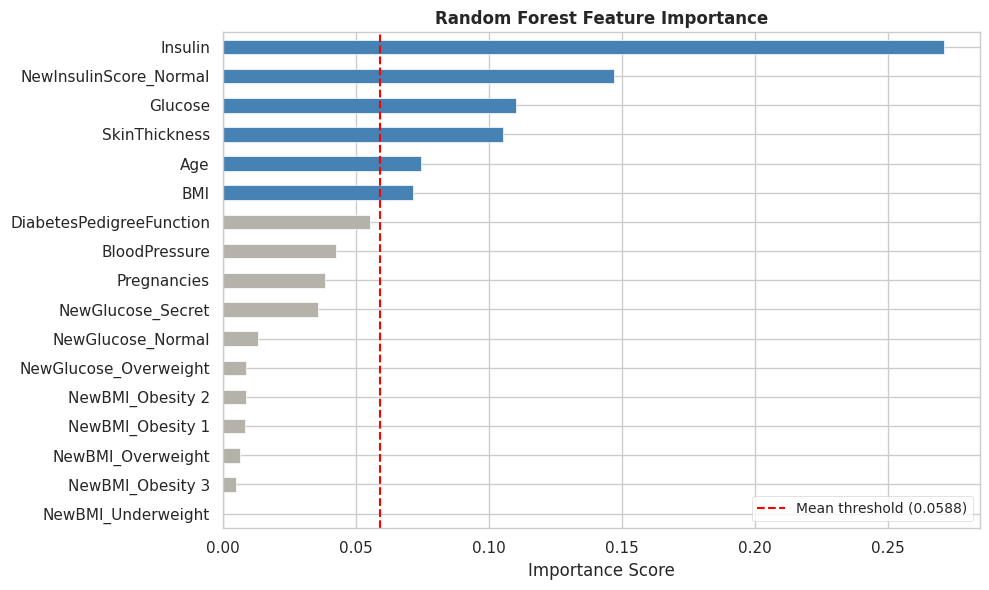

Selected 6 features: ['Glucose', 'SkinThickness', 'Insulin', 'BMI', 'Age', 'NewInsulinScore_Normal']
Dropped 11 features: ['Pregnancies', 'BloodPressure', 'DiabetesPedigreeFunction', 'NewBMI_Obesity 1', 'NewBMI_Obesity 2', 'NewBMI_Obesity 3', 'NewBMI_Overweight', 'NewBMI_Underweight', 'NewGlucose_Normal', 'NewGlucose_Overweight', 'NewGlucose_Secret']
X_train shape: (786, 6)
X_test shape: (154, 6)


In [ ]:
# # Feature Selection: Random Forest Importance
# from sklearn.ensemble import RandomForestClassifier as SkRF
# from sklearn.feature_selection import SelectFromModel

# rf_sk = SkRF(n_estimators=200, random_state=42, n_jobs=-1)
# rf_sk.fit(X_train, y_train)

# # Plot feature importances
# fig, ax = plt.subplots(figsize=(10, 6))
# feat_imp = pd.Series(rf_sk.feature_importances_, index=all_feature_names)
# feat_imp.sort_values().plot(kind='barh', ax=ax, color='steelblue')
# ax.set_title('Random Forest Feature Importance', fontsize=12, fontweight='bold')
# ax.set_xlabel('Importance Score')
# plt.tight_layout()
# plt.show()

# # Select features with importance
# selector = SelectFromModel(rf_sk, threshold='mean', prefit=True)
# selected_mask = selector.get_support()
# selected_features = [all_feature_names[i] for i in range(len(all_feature_names)) if selected_mask[i]]
# dropped_features = [all_feature_names[i] for i in range(len(all_feature_names)) if not selected_mask[i]]

# X_train = X_train[:, selected_mask]
# X_test = X_test[:, selected_mask]

# print(f"Selected {len(selected_features)} features: {selected_features}")
# print(f"Dropped {len(dropped_features)} features: {dropped_features}")
# print(f"X_train shape: {X_train.shape}")
# print(f"X_test shape: {X_test.shape}")
# Feature Selection: Random Forest Importance (with balanced class weights)
from sklearn.ensemble import RandomForestClassifier as SkRF
from sklearn.feature_selection import SelectFromModel

rf_sk = SkRF(n_estimators=200, random_state=42, n_jobs=-1, class_weight='balanced')
rf_sk.fit(X_train, y_train)

# Plot feature importances with threshold line
fig, ax = plt.subplots(figsize=(10, 6))
feat_imp = pd.Series(rf_sk.feature_importances_, index=all_feature_names)
feat_imp_sorted = feat_imp.sort_values()
threshold = feat_imp.mean()

colors = ['steelblue' if v >= threshold else '#B4B2A9' for v in feat_imp_sorted.values]
feat_imp_sorted.plot(kind='barh', ax=ax, color=colors)

ax.axvline(x=threshold, color='red', linestyle='--', linewidth=1.5, label=f'Mean threshold ({threshold:.4f})')
ax.legend(loc='lower right', fontsize=10)
ax.set_title('Random Forest Feature Importance', fontsize=12, fontweight='bold')
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.show()

# Select features with importance
selector = SelectFromModel(rf_sk, threshold='mean', prefit=True)
selected_mask = selector.get_support()
selected_features = [all_feature_names[i] for i in range(len(all_feature_names)) if selected_mask[i]]
dropped_features = [all_feature_names[i] for i in range(len(all_feature_names)) if not selected_mask[i]]

X_train = X_train[:, selected_mask]
X_test = X_test[:, selected_mask]

print(f"Selected {len(selected_features)} features: {selected_features}")
print(f"Dropped {len(dropped_features)} features: {dropped_features}")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")


# Traning the Hyperparameterized Models

In [ ]:
# Logistic Regression - Hyperparameter Tuning
lr_grid = {'C': [0.01, 0.1, 1, 10, 100], 'penalty': ['l2'], 'solver': ['lbfgs'], 'max_iter': [2000]}
lr_search = GridSearchCV(LogisticRegression(random_state=42), lr_grid,
                         cv=StratifiedKFold(5, shuffle=True, random_state=42), n_jobs=-1)
lr_search.fit(X_train, y_train)
print(f"Best LR params: {lr_search.best_params_}, CV Score: {lr_search.best_score_:.4f}")
log_reg = lr_search.best_estimator_


In [ ]:
y_pred = log_reg.predict(X_test)

In [ ]:
accuracy_score(y_train, log_reg.predict(X_train))

0.8371501272264631

In [ ]:
log_reg_acc = accuracy_score(y_test, log_reg.predict(X_test))

In [ ]:
confusion_matrix(y_test, y_pred)

array([[92, 15],
       [ 5, 42]])

In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.95      0.86      0.90       107
           1       0.74      0.89      0.81        47

    accuracy                           0.87       154
   macro avg       0.84      0.88      0.85       154
weighted avg       0.88      0.87      0.87       154



In [ ]:
# KNN - Hyperparameter Tuning
knn_grid = {
    'n_neighbors': [3, 5, 7, 9, 11, 13, 15, 17, 19, 21],
    'weights': ['uniform', 'distance'],
    'p': [1, 2],
}
knn_search = GridSearchCV(KNeighborsClassifier(), knn_grid,
                          cv=StratifiedKFold(5, shuffle=True, random_state=42), n_jobs=-1)
knn_search.fit(X_train, y_train)
knn = knn_search.best_estimator_
print(f"Best KNN: {knn_search.best_params_}, CV={knn_search.best_score_:.4f}")

y_pred = knn.predict(X_test)
print("Train acc:", accuracy_score(y_train, knn.predict(X_train)))
knn_acc = accuracy_score(y_test, y_pred)
print("Test acc :", knn_acc)
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))


In [ ]:
# SVM - Hyperparameter Tuning
svm_grid = {'gamma': [0.001, 0.005, 0.01, 0.05], 'C': [1, 5, 10, 20]}
svm_search = GridSearchCV(SVC(probability=True, random_state=42), svm_grid,
                          cv=StratifiedKFold(3, shuffle=True, random_state=42), n_jobs=-1)
svm_search.fit(X_train, y_train)
best_params_svm = svm_search.best_params_
best_score_svm = svm_search.best_score_
print("SVM Grid Search Complete")


In [ ]:
# best_parameter
best_params_svm



{'C': 20, 'gamma': 0.05}

In [ ]:
best_score_svm



np.float64(0.8409669211195929)

In [ ]:
svc = svm_search.best_estimator_
y_pred = svc.predict(X_test)
print(f"Best SVM params: {best_params_svm}")
print("Train acc:", accuracy_score(y_train, svc.predict(X_train)))
svc_acc = accuracy_score(y_test, y_pred)
print("Test acc :", svc_acc)
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))


In [ ]:
# Random Forest
rand_clf = RandomForestClassifier(
    criterion='entropy', max_depth=15, max_features=0.75,
    min_samples_leaf=2, min_samples_split=3, n_estimators=130,
    random_state=42, n_jobs=-1,
)
rand_clf.fit(X_train, y_train)


In [ ]:
y_pred = rand_clf.predict(X_test)

In [ ]:
y_pred = rand_clf.predict(X_test)
print(accuracy_score(y_train, rand_clf.predict(X_train)))
rand_acc = accuracy_score(y_test, rand_clf.predict(X_test))
print(accuracy_score(y_test, rand_clf.predict(X_test)))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

0.9961832061068703
0.8896103896103896
[[95 12]
 [ 5 42]]
              precision    recall  f1-score   support

           0       0.95      0.89      0.92       107
           1       0.78      0.89      0.83        47

    accuracy                           0.89       154
   macro avg       0.86      0.89      0.87       154
weighted avg       0.90      0.89      0.89       154



In [ ]:
# XGBoost - Hyperparameter Tuning
xgb_grid = {
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 5, 6],
    'n_estimators': [50, 100],
    'reg_lambda': [0.5, 1.0],
}
xgb_search = GridSearchCV(
    XGBClassifier(objective='binary:logistic', eval_metric='logloss', random_state=42, n_jobs=1),
    xgb_grid,
    cv=StratifiedKFold(3, shuffle=True, random_state=42),
    n_jobs=-1,
)
xgb_search.fit(X_train, y_train)
xgb = xgb_search.best_estimator_
print(f"Best XGB params: {xgb_search.best_params_}, CV Score: {xgb_search.best_score_:.4f}")


In [ ]:
y_pred = xgb.predict(X_test)
print(accuracy_score(y_train, xgb.predict(X_train)))
xgb_acc = accuracy_score(y_test, xgb.predict(X_test))
print(accuracy_score(y_test, xgb.predict(X_test)))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

0.9872773536895675
0.8896103896103896
[[95 12]
 [ 5 42]]
              precision    recall  f1-score   support

           0       0.95      0.89      0.92       107
           1       0.78      0.89      0.83        47

    accuracy                           0.89       154
   macro avg       0.86      0.89      0.87       154
weighted avg       0.90      0.89      0.89       154



In [ ]:
# Model Comparison
models = pd.DataFrame({
    'Model': ['Logistic Regression', 'KNN', 'SVM', 'Random Forest Classifier', 'XgBoost'],
    'Score': [100*round(log_reg_acc,4), 100*round(knn_acc,4), 100*round(svc_acc,4),
              100*round(rand_acc,4), 100*round(xgb_acc,4)]
})
models.sort_values(by = 'Score', ascending = False)


,Model,Score
2,SVM,90.91
4,XgBoost,88.96
3,Random Forest Classifier,88.96
1,KNN,88.31
0,Logistic Regression,87.01


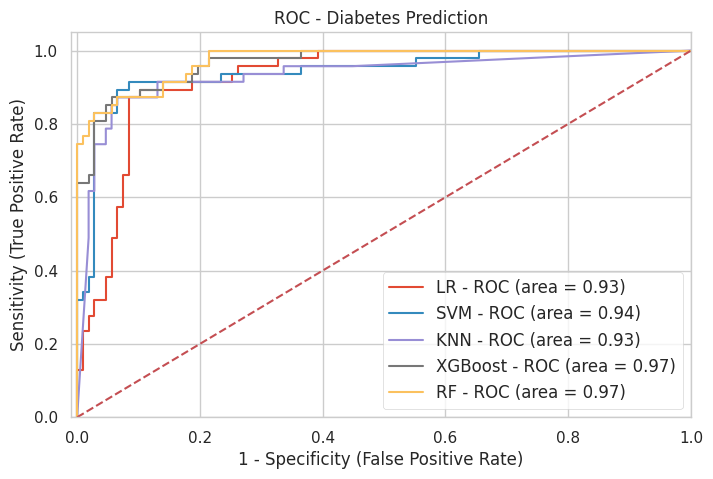

In [ ]:
plt.figure(figsize=(8,5))
models = [
{
    'label': 'LR',
    'model': log_reg,
},
{
    'label': 'SVM',
    'model': svc,
},
{
    'label': 'KNN',
    'model': knn,
},
{
    'label': 'XGBoost',
    'model': xgb,
},
{
    'label': 'RF',
    'model': rand_clf,
}
]
for m in models:
    model = m['model']
    model.fit(X_train, y_train)
    y_pred=model.predict(X_test)
    fpr1, tpr1, thresholds = roc_curve(y_test, model.predict_proba(X_test)[:,1])
    auc = roc_auc_score(y_test, model.predict_proba(X_test)[:, 1])
    plt.plot(fpr1, tpr1, label='%s - ROC (area = %0.2f)' % (m['label'], auc))

plt.plot([0, 1], [0, 1],'r--')
plt.xlim([-0.01, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('1 - Specificity (False Positive Rate)', fontsize=12)
plt.ylabel('Sensitivity (True Positive Rate)', fontsize=12)
plt.title('ROC - Diabetes Prediction', fontsize=12)
plt.legend(loc="lower right", fontsize=12)
plt.savefig("roc_diabetes.jpeg", format='jpeg', dpi=400, bbox_inches='tight')
plt.show()


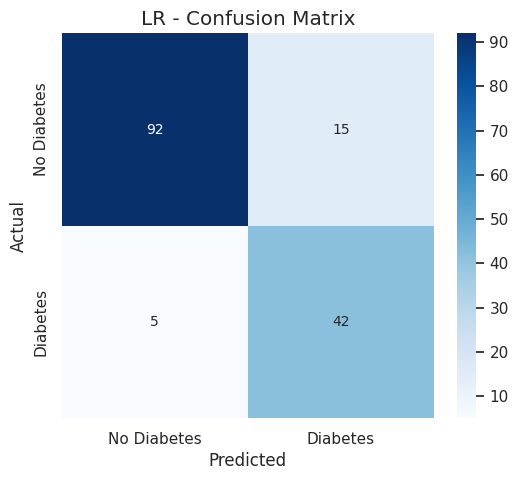

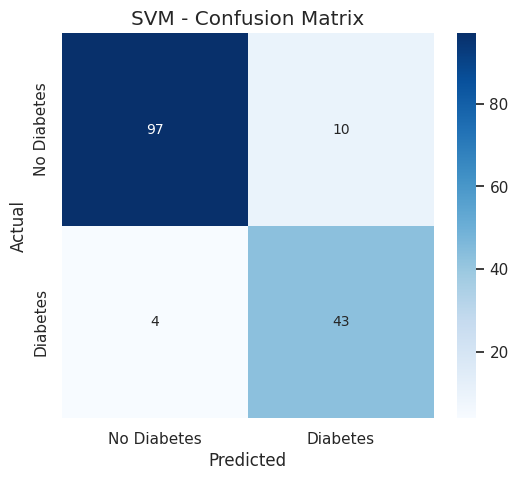

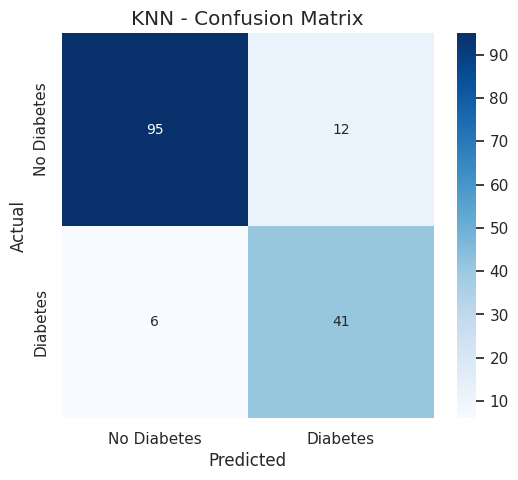

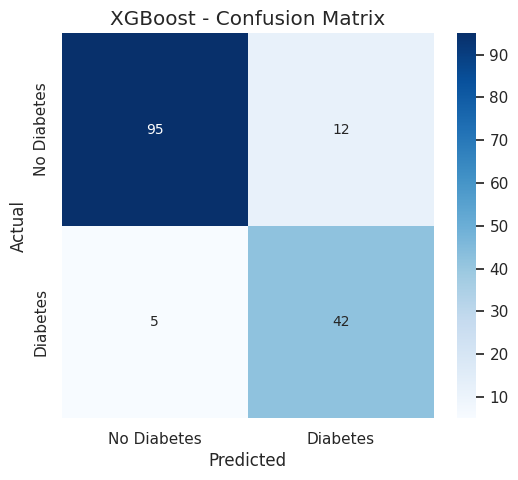

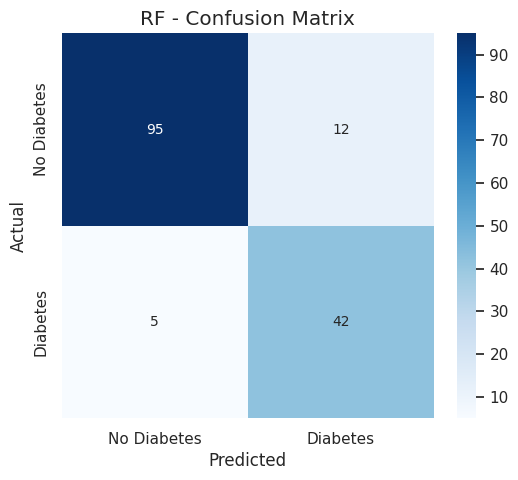

In [ ]:
# Confusion Matrix
import seaborn as sns
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

models = [
    {'label': 'LR', 'model': log_reg},
    {'label': 'SVM', 'model': svc},
    {'label': 'KNN', 'model': knn},
    {'label': 'XGBoost', 'model': xgb},
    {'label': 'RF', 'model': rand_clf}
]

for m in models:
    model = m['model']

    # Train
    model.fit(X_train, y_train)

    # Predict
    y_pred = model.predict(X_test)

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)

    # Plot (LIKE YOUR IMAGE)
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['No Diabetes', 'Diabetes'],
                yticklabels=['No Diabetes', 'Diabetes'])

    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title(f"{m['label']} - Confusion Matrix")

    plt.savefig(f"cm_{m['label']}.jpeg", dpi=400, bbox_inches='tight')
    plt.show()

# Model Comparison

[87.01, 90.91, 88.31, 88.96, 88.96]
[np.float64(87.67), np.float64(90.60000000000001), np.float64(88.01), np.float64(89.07000000000001), np.float64(87.67)]


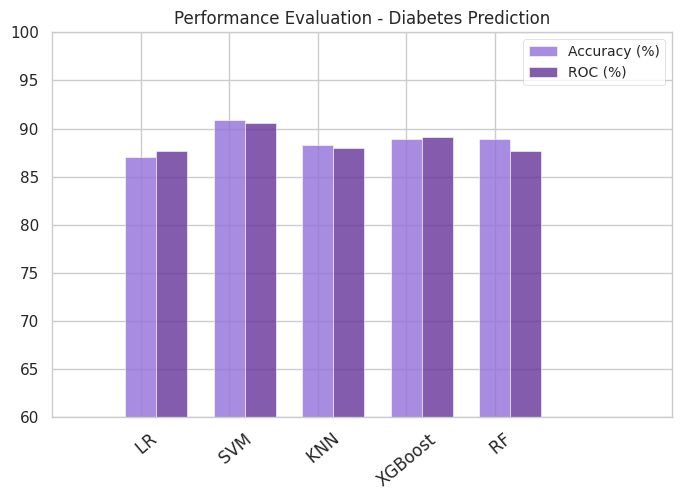

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
models = [
{
    'label': 'LR',
    'model': log_reg,
},
{
    'label': 'SVM',
    'model': svc,
},
{
    'label': 'KNN',
    'model': knn,
},
{
    'label': 'XGBoost',
    'model': xgb,
},
{
    'label': 'RF',
    'model': rand_clf,
}
]

means_roc = []
means_accuracy = [100*round(log_reg_acc,4), 100*round(svc_acc,4), 100*round(knn_acc,4), 100*round(xgb_acc,4),
                  100*round(rand_acc,4)]

for m in models:
    model = m['model']
    model.fit(X_train, y_train)
    y_pred=model.predict(X_test)
    fpr1, tpr1, thresholds = roc_curve(y_test, model.predict_proba(X_test)[:,1])
    auc = roc_auc_score(y_test,model.predict(X_test))
    auc = 100*round(auc,4)
    means_roc.append(auc)

print(means_accuracy)
print(means_roc)

# data to plot
n_groups = 5
means_accuracy = tuple(means_accuracy)
means_roc = tuple(means_roc)

# create plot
fig, ax = plt.subplots(figsize=(8,5))
index = np.arange(n_groups)
bar_width = 0.35
opacity = 0.8

rects1 = plt.bar(index, means_accuracy, bar_width,
alpha=opacity,
color='mediumpurple',
label='Accuracy (%)')

rects2 = plt.bar(index + bar_width, means_roc, bar_width,
alpha=opacity,
color='rebeccapurple',
label='ROC (%)')

plt.xlim([-1, 6])
plt.ylim([60, 100])

plt.title('Performance Evaluation - Diabetes Prediction', fontsize=12)
plt.xticks(index, ('   LR', '   SVM', '   KNN', 'XGBoost', '   RF'), rotation=40, ha='center', fontsize=12)
plt.legend(loc="upper right", fontsize=10)
plt.savefig("PE_diabetes.jpeg", format='jpeg', dpi=400, bbox_inches='tight')
plt.show()


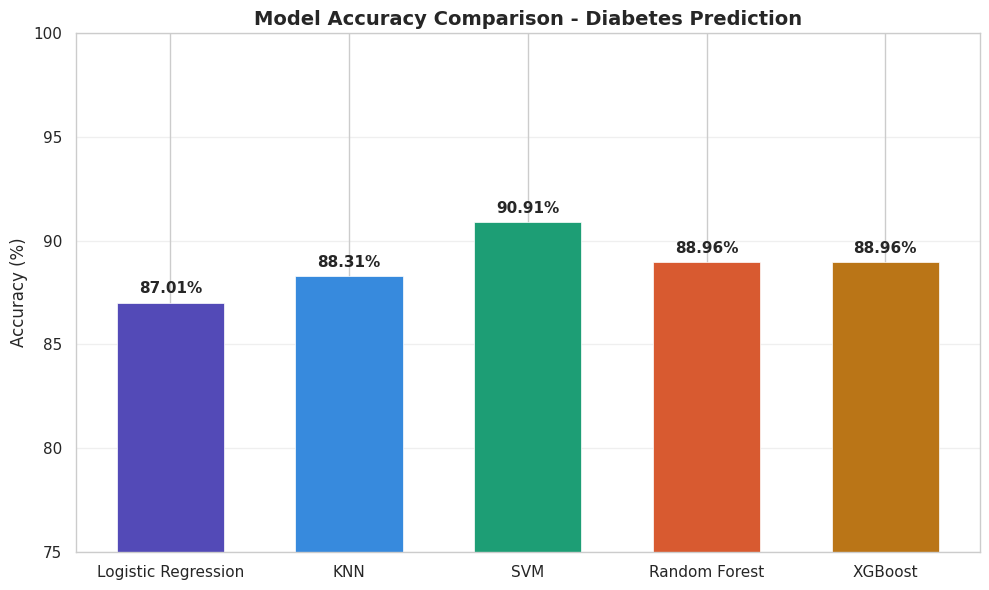

In [ ]:
# # Model Accuracy and Recall Comparison
# fig, ax = plt.subplots(figsize=(10, 6))

# models_list = ['Logistic Regression', 'KNN', 'SVM', 'Random Forest', 'XGBoost']
# accuracies = [log_reg_acc * 100, knn_acc * 100, svc_acc * 100, rand_acc * 100, xgb_acc * 100]

# # Get recall scores
# recalls = []
# for model in [log_reg, knn, svc, rand_clf, xgb]:
#     y_pred = model.predict(X_test)
#     recalls.append(recall_score(y_test, y_pred) * 100)

# x = np.arange(len(models_list))
# width = 0.3

# bars1 = ax.bar(x - width/2, accuracies, width, label='Accuracy', color='#378ADD', edgecolor='white')
# bars2 = ax.bar(x + width/2, recalls, width, label='Recall', color='#D85A30', edgecolor='white')

# for bar in bars1:
#     height = bar.get_height()
#     ax.text(bar.get_x() + bar.get_width() / 2, height + 0.3,
#             f'{height:.2f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')

# for bar in bars2:
#     height = bar.get_height()
#     ax.text(bar.get_x() + bar.get_width() / 2, height + 0.3,
#             f'{height:.2f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')

# ax.set_ylabel('Score (%)', fontsize=12)
# ax.set_title('Model Accuracy vs Recall - Diabetes Prediction', fontsize=14, fontweight='bold')
# ax.set_ylim(75, 100)
# ax.set_xticks(x)
# ax.set_xticklabels(models_list, fontsize=11)
# ax.legend(fontsize=11)
# ax.grid(axis='y', alpha=0.3)
# plt.tight_layout()
# plt.savefig("model_accuracy_recall_comparison.jpeg", dpi=400, bbox_inches='tight')
# plt.show()

# Model Accuracy Comparison
fig, ax = plt.subplots(figsize=(10, 6))

models_list = ['Logistic Regression', 'KNN', 'SVM', 'Random Forest', 'XGBoost']
accuracies = [log_reg_acc * 100, knn_acc * 100, svc_acc * 100, rand_acc * 100, xgb_acc * 100]
colors = ['#534AB7', '#378ADD', '#1D9E75', '#D85A30', '#BA7517']

bars = ax.bar(models_list, accuracies, color=colors, width=0.6, edgecolor='white')

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, height + 0.3,
            f'{height:.2f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_ylabel('Accuracy (%)', fontsize=12)
ax.set_title('Model Accuracy Comparison - Diabetes Prediction', fontsize=14, fontweight='bold')
ax.set_ylim(75, 100)
ax.grid(axis='y', alpha=0.3)
plt.xticks(fontsize=11)
plt.tight_layout()
plt.savefig("model_accuracy_comparison.jpeg", dpi=400, bbox_inches='tight')
plt.show()



                     Accuracy  Recall  F1-score  Precision    ROC
Model                                                            
Logistic Regression     87.01   89.36     80.77      73.68  92.58
KNN                     88.31   87.23     82.00      77.36  93.32
SVM                     90.26   91.49     85.15      79.63  94.29
Random Forest           87.01   89.36     80.77      73.68  96.98
XGBoost                 88.96   89.36     83.17      77.78  96.66


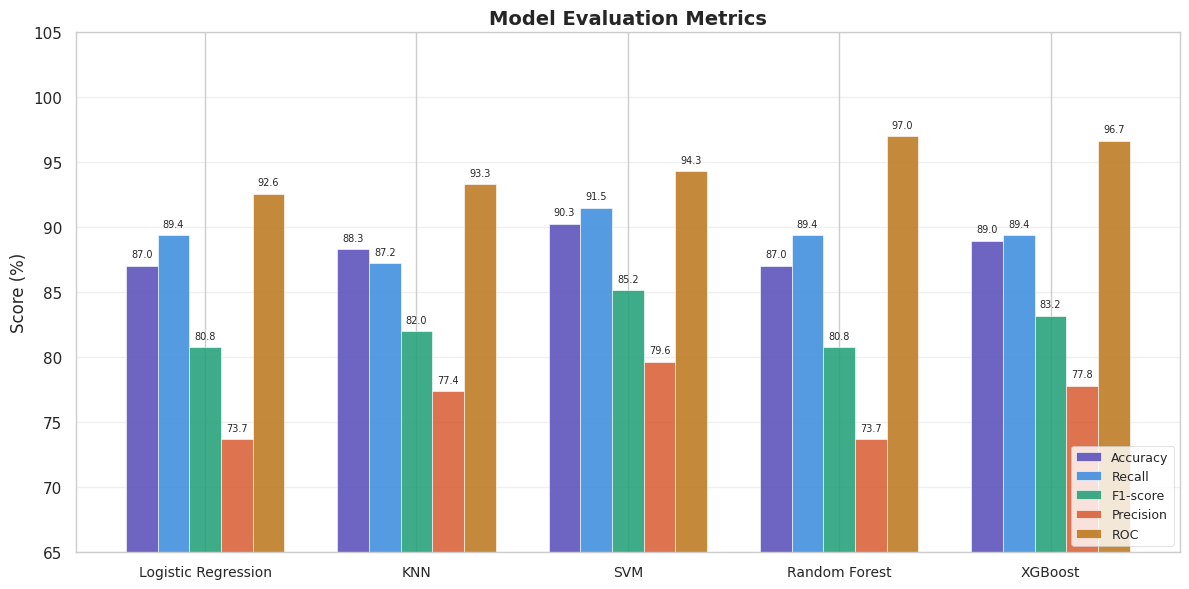

In [ ]:
# Evaluation Metrics - All Models
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

all_models = [
    {'label': 'Logistic Regression', 'model': log_reg},
    {'label': 'KNN', 'model': knn},
    {'label': 'SVM', 'model': svc},
    {'label': 'Random Forest', 'model': rand_clf},
    {'label': 'XGBoost', 'model': xgb},
]

rows = []
for m in all_models:
    model = m['model']
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    rows.append({
        'Model': m['label'],
        'Accuracy': round(accuracy_score(y_test, y_pred) * 100, 2),
        'Recall': round(recall_score(y_test, y_pred) * 100, 2),
        'F1-score': round(f1_score(y_test, y_pred) * 100, 2),
        'Precision': round(precision_score(y_test, y_pred) * 100, 2),
        'ROC': round(roc_auc_score(y_test, y_proba) * 100, 2),
    })

results_df = pd.DataFrame(rows).set_index('Model')
print(results_df.to_string())

# Grouped Bar Chart
fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(results_df))
width = 0.15
colors = ['#534AB7', '#378ADD', '#1D9E75', '#D85A30', '#BA7517']

for i, col in enumerate(results_df.columns):
    bars = ax.bar(x + i * width, results_df[col], width, label=col, color=colors[i], alpha=0.85)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'{bar.get_height():.1f}', ha='center', va='bottom', fontsize=7)

ax.set_ylabel('Score (%)')
ax.set_title('Model Evaluation Metrics', fontsize=14, fontweight='bold')
ax.set_xticks(x + width * 2)
ax.set_xticklabels(results_df.index, fontsize=10)
ax.set_ylim(65, 105)
ax.legend(loc='lower right', fontsize=9)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig("evaluation_metrics.jpeg", dpi=400, bbox_inches='tight')
plt.show()

                     Accuracy  Recall
Model                                
Logistic Regression     87.01   89.36
KNN                     88.31   87.23
SVM                     90.26   91.49
Random Forest           87.01   89.36
XGBoost                 88.96   89.36


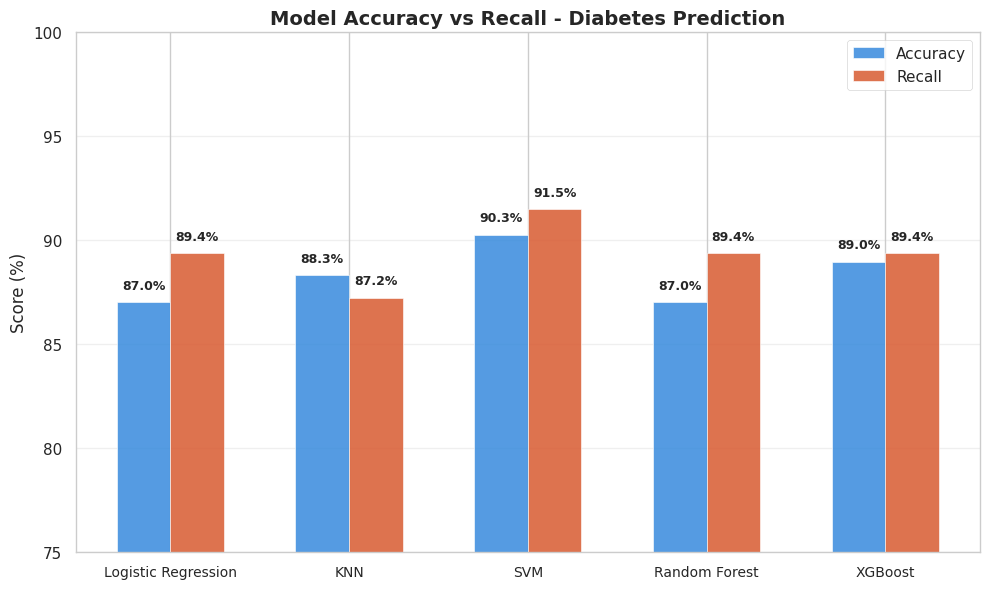

In [ ]:
# Evaluation Metrics - Accuracy and Recall
from sklearn.metrics import accuracy_score, recall_score
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

all_models = [
    {'label': 'Logistic Regression', 'model': log_reg},
    {'label': 'KNN', 'model': knn},
    {'label': 'SVM', 'model': svc},
    {'label': 'Random Forest', 'model': rand_clf},
    {'label': 'XGBoost', 'model': xgb},
]

rows = []
for m in all_models:
    model = m['model']
    y_pred = model.predict(X_test)
    rows.append({
        'Model': m['label'],
        'Accuracy': round(accuracy_score(y_test, y_pred) * 100, 2),
        'Recall': round(recall_score(y_test, y_pred) * 100, 2),
    })

results_df = pd.DataFrame(rows).set_index('Model')
print(results_df.to_string())

# Grouped Bar Chart
fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(results_df))
width = 0.3

bars1 = ax.bar(x - width/2, results_df['Accuracy'], width, label='Accuracy', color='#378ADD', alpha=0.85)
bars2 = ax.bar(x + width/2, results_df['Recall'], width, label='Recall', color='#D85A30', alpha=0.85)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')

for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_ylabel('Score (%)')
ax.set_title('Model Accuracy vs Recall - Diabetes Prediction', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(results_df.index, fontsize=10)
ax.set_ylim(75, 100)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig("accuracy_recall_comparison.jpeg", dpi=400, bbox_inches='tight')
plt.show()